<h1 align='center' style='color:red'>Credit Risk Modeling Project</h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
import warnings

warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

### Load Data

In [2]:
df = pd.read_csv('credit_risk_data.csv')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


Dataset:
This project uses the Credit Risk dataset provided by CodeBasics.
Please download the dataset from the original source and place it in the data/ folder before running the notebook.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

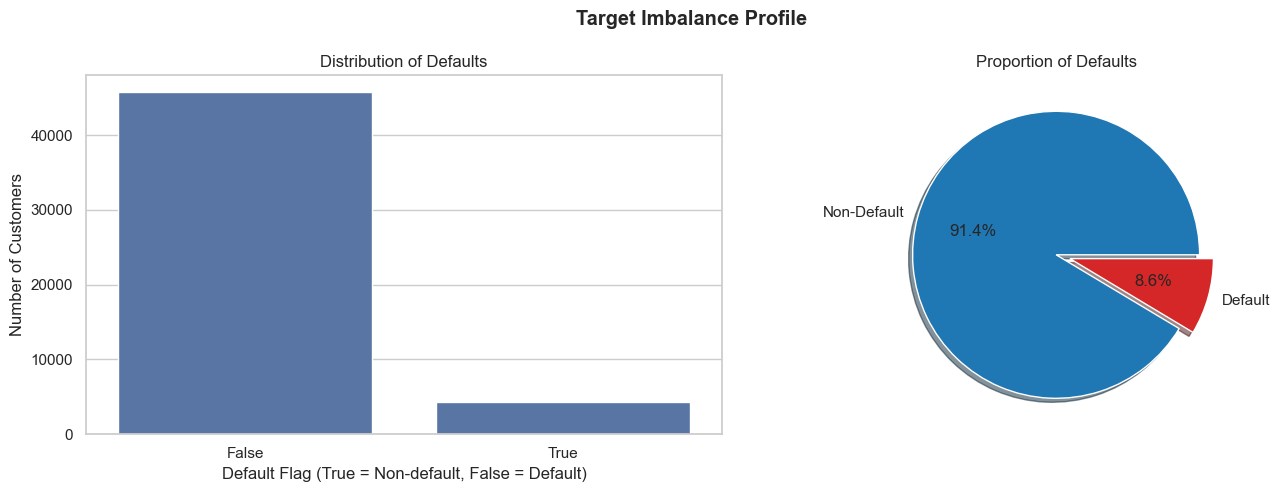

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Target count plot
sns.countplot(x='default', data=df, ax=ax[0])
ax[0].set_title('Distribution of Defaults')
ax[0].set_xlabel('Default Flag (True = Non-default, False = Default)')
ax[0].set_ylabel('Number of Customers')

# Pie chart showing proportions
df['default'].value_counts().plot.pie(
    explode=[0, 0.1], 
    autopct='%1.1f%%', 
    ax=ax[1], 
    shadow=True, 
    colors=['#1f77b4', '#d62728'],
    labels=['Non-Default', 'Default'],
)
ax[1].set_title('Proportion of Defaults')
ax[1].set_ylabel('')

plt.suptitle('Target Imbalance Profile', weight='bold')
plt.tight_layout()
plt.savefig("class_imbalance_plot.png", dpi=300, bbox_inches="tight")  # PNG, 300 DPI
plt.show()

In [5]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

default is a target variable and we can see some class imbalance here.

### Train-Test Split to Prevent Data Leakage

Before building the model, the dataset was divided into training and testing sets. This was done to prevent **data leakage** and ensure an accurate evaluation of the model.

**Data leakage** happens when the model accidentally gets information from the test data while learning. It is similar to a student seeing exam questions before the exam. The student may score very well in the test, but the result does not reflect their actual knowledge.

In the same way, if a machine learning model has access to test data during training, it may appear highly accurate, but its performance on new real-world data will be much lower.

By splitting the data first, the model learns only from the training data and is tested on completely unseen data, giving a realistic measure of its performance.

In [6]:
X = df.drop("default", axis="columns")
y = df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

print(df_train.shape)
df_train.head(2)

(37500, 33)


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0


<h3 align="center" style="color:blue">Data Cleaning</h3>

### Handle Missing & Duplicate Values

In [7]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [8]:
df_train.duplicated().sum()

0

In [9]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [10]:
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [11]:
df_train.residence_type.fillna(mode_residence, inplace=True)
df_test.residence_type.fillna(mode_residence, inplace=True)

df_train.residence_type.unique(), df_test.residence_type.unique()

(array(['Owned', 'Mortgage', 'Rented'], dtype=object),
 array(['Owned', 'Mortgage', 'Rented'], dtype=object))

In [12]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,37500.00,39.54,9.86,18.00,33.00,39.00,46.00,70.00
income,37500.00,2633326.16,2623780.52,0.00,802000.00,1885000.00,3326250.00,11999000.00
number_of_dependants,37500.00,1.94,1.54,0.00,0.00,2.00,3.00,5.00
years_at_current_address,37500.00,16.00,8.92,1.00,8.00,16.00,24.00,31.00
zipcode,37500.00,418866.25,169035.02,110001.00,302001.00,400001.00,560001.00,700001.00
sanction_amount,37500.00,4699691.57,6257832.98,0.00,1142000.00,2644000.00,5178000.00,52175000.00
loan_amount,37500.00,3996067.73,5371862.29,0.00,961000.00,2230000.00,4619000.00,47819000.00
processing_fee,37500.00,80290.68,113128.14,0.00,19220.00,44600.00,92420.00,5293543.52
gst,37500.00,719292.19,966935.21,0.00,172980.00,401400.00,831420.00,8607420.00
net_disbursement,37500.00,3196854.19,4297489.83,0.00,768800.00,1784000.00,3695200.00,38255200.00


In [13]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [14]:
columns_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 
                      'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 
                      'loan_tenure_months','principal_outstanding', 'bank_balance_at_application',
                      'number_of_open_accounts','number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
                       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

columns_categorical = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 
                       'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

### Box plot to visualize outliers

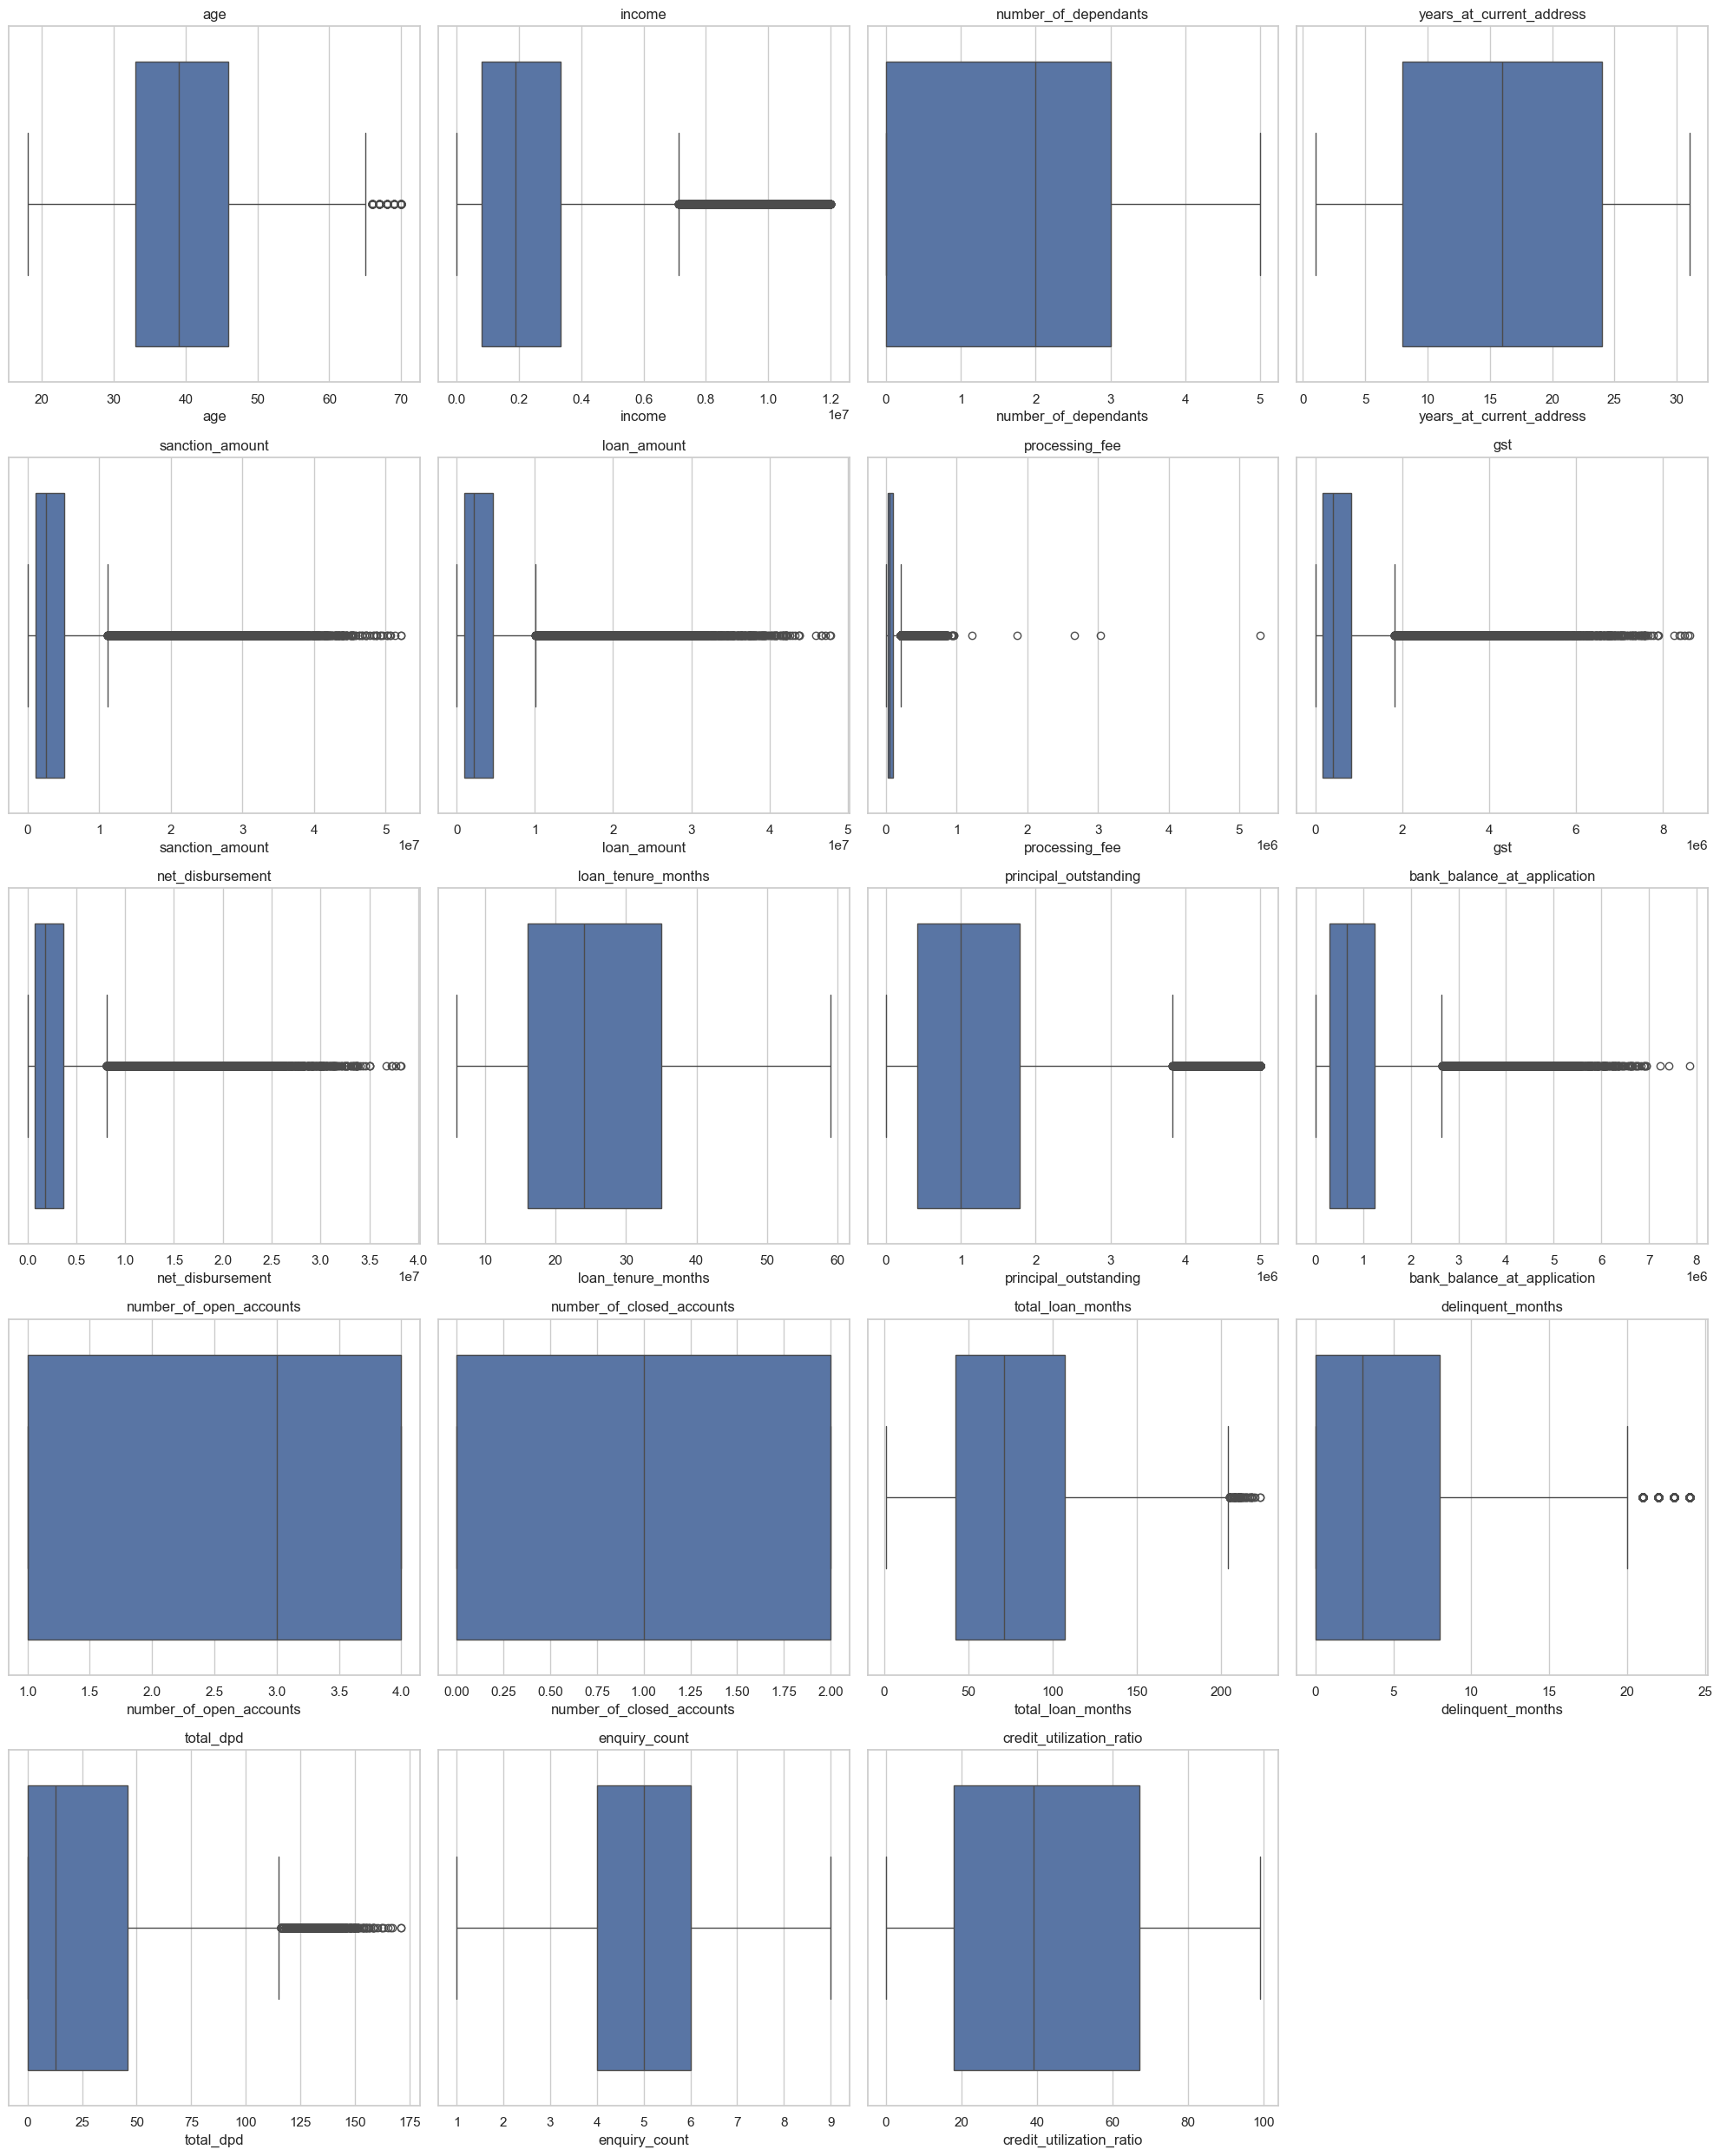

In [15]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

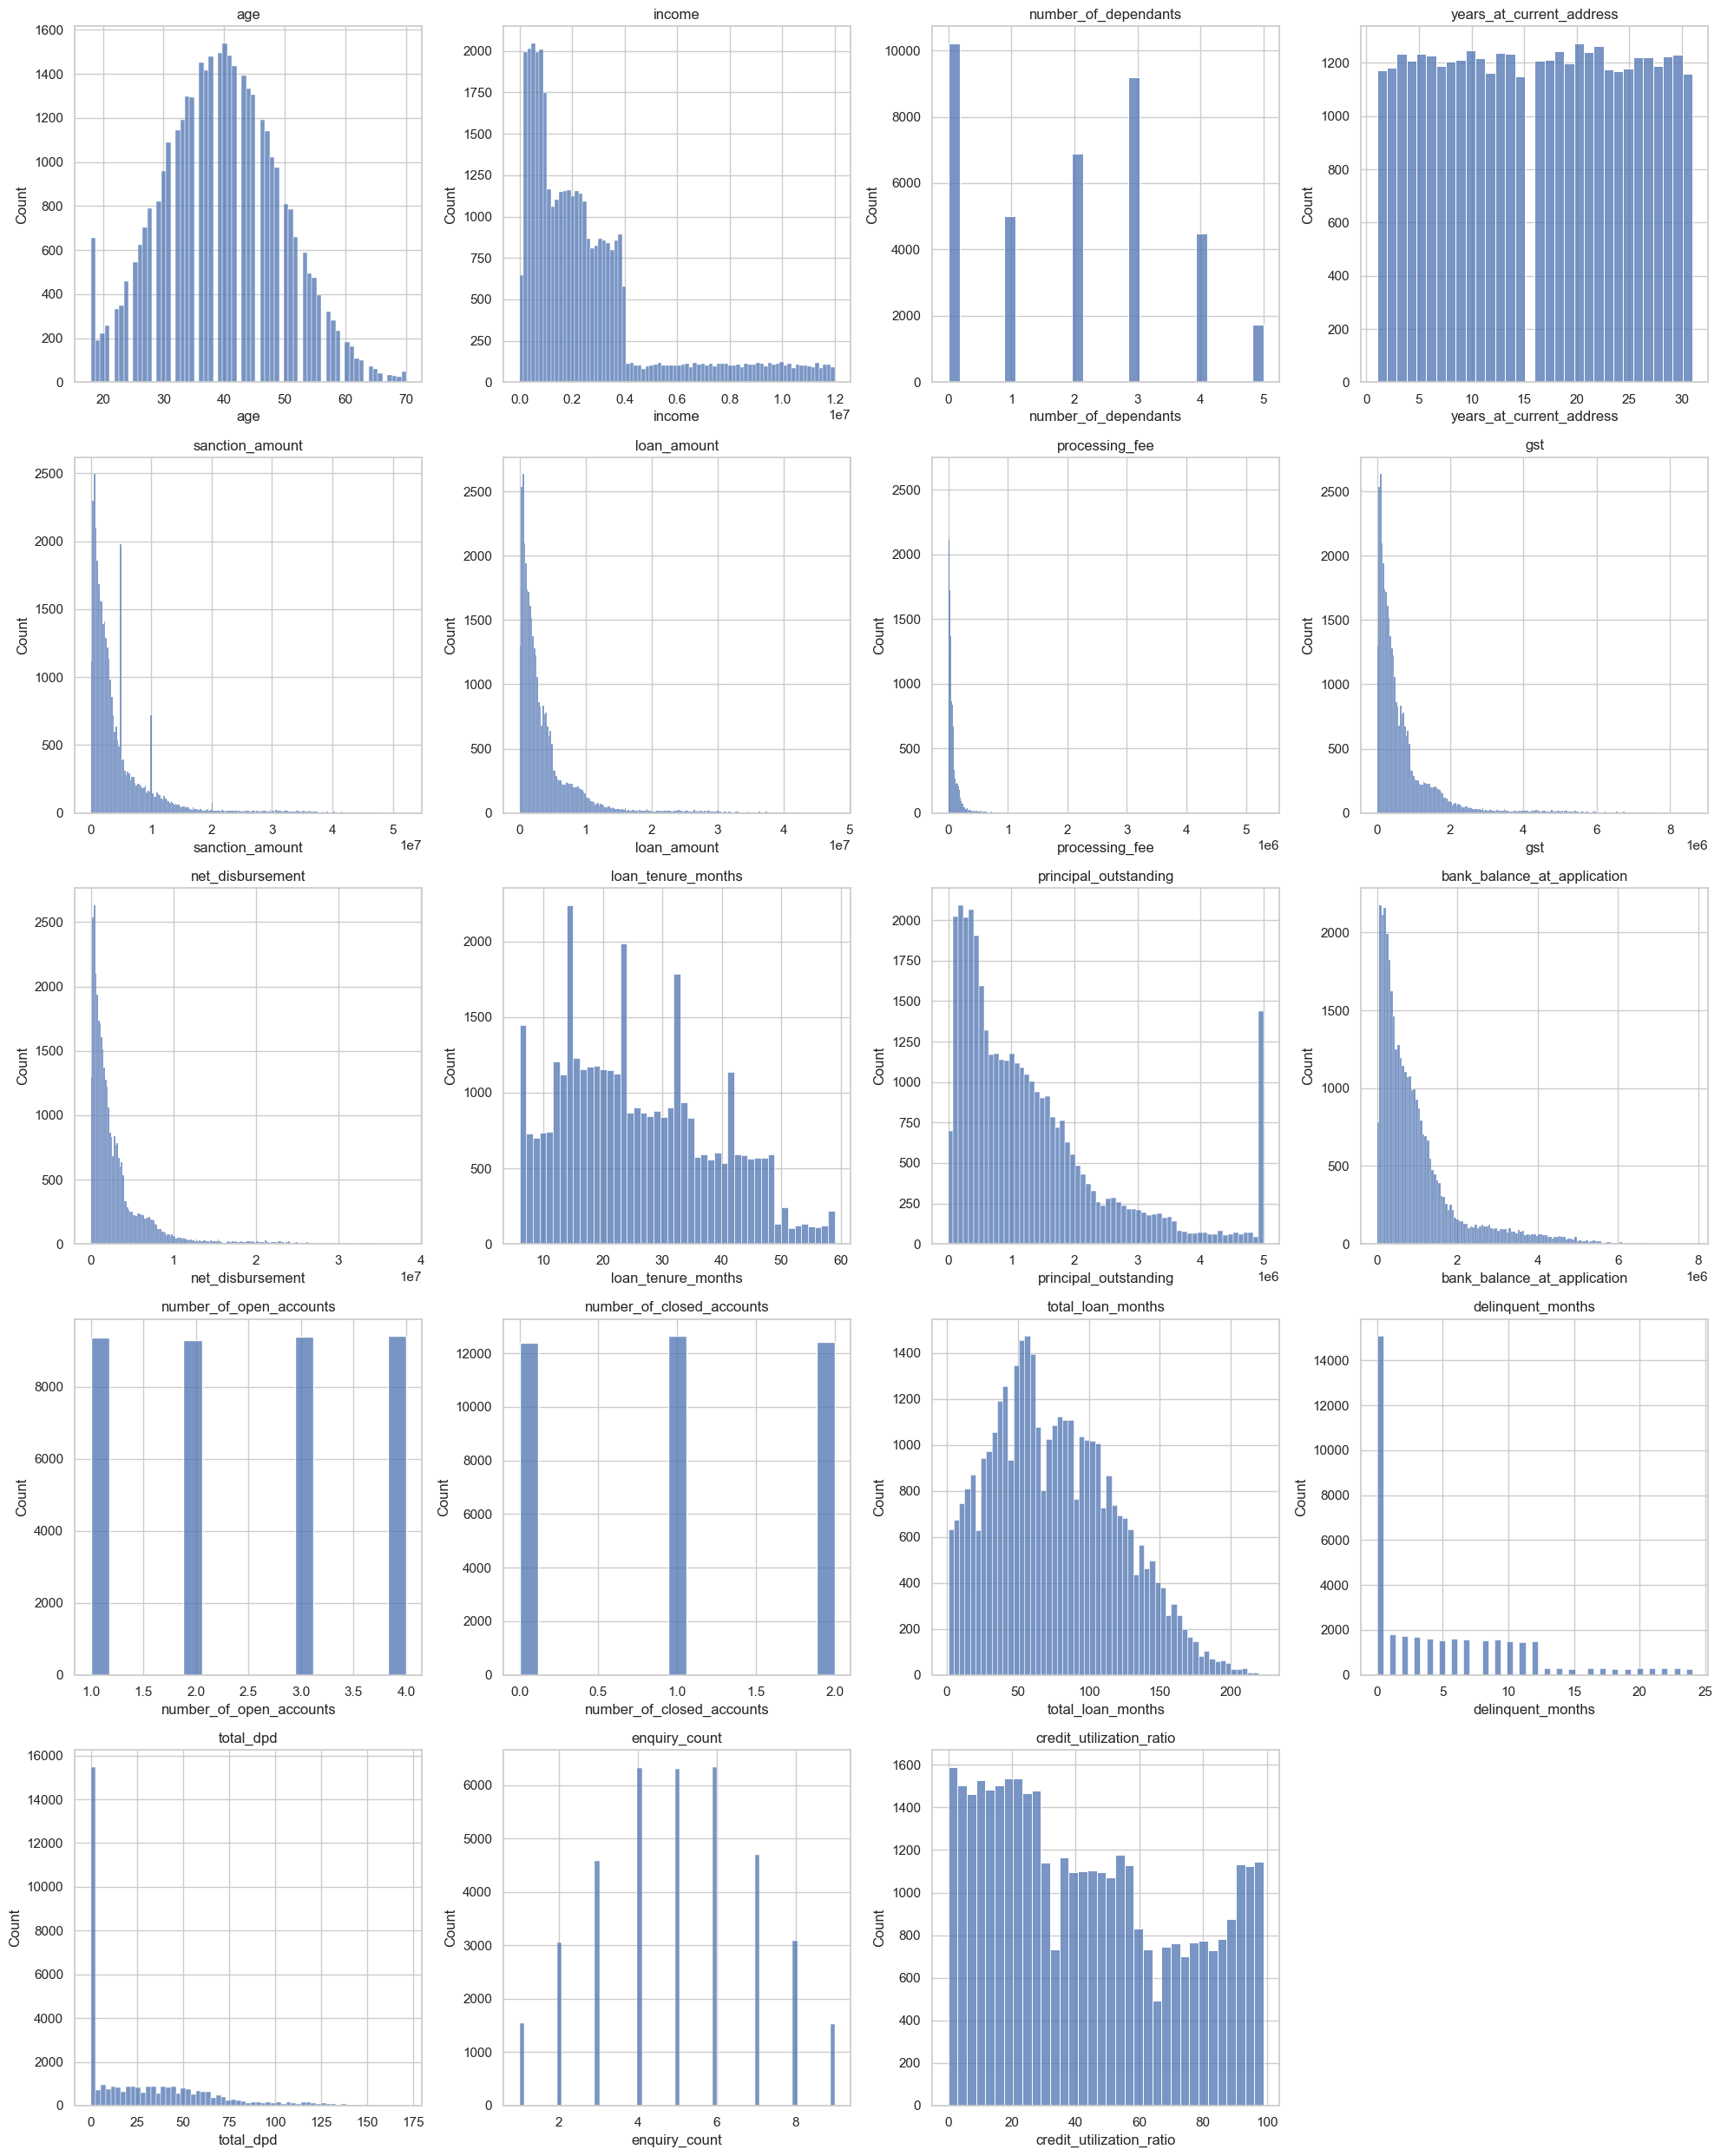

In [16]:
num_plots = len(columns_continuous)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(columns_continuous):
    sns.histplot(df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Outlier Removal: Processing Fee

In [17]:
df_train.processing_fee.describe()

count     37500.00
mean      80290.68
std      113128.14
min           0.00
25%       19220.00
50%       44600.00
75%       92420.00
max     5293543.52
Name: processing_fee, dtype: float64

In [18]:
df_train[df_train.processing_fee > df_train.processing_fee][['loan_amount', 'processing_fee']]

,loan_amount,processing_fee


In [19]:
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][["loan_amount","processing_fee"]]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


In [20]:
df_train = df_train[df_train.processing_fee/df_train.loan_amount<0.03].copy()
df_train.shape

(37488, 33)

In [21]:
df_test.residence_type.isna().sum()

0

In [22]:
# Apply same step on test set
df_test = df_test[df_test.processing_fee/df_test.loan_amount<0.03].copy()
df_test.shape

(12497, 33)

In [23]:
# Use other business rules for data validation
# Rule 1: GST should not be more than 20%

df_train[(df_train.gst/df_train.loan_amount)>0.2].shape

(0, 33)

In [24]:
# Rule 2: Net disbursement should not be higher than loan_amount
df_train[df_train.net_disbursement>df_train.loan_amount].shape

(0, 33)

No rows found that breaks rule 1 and rule 2

### Analyze Categorical Columns

In [25]:
columns_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [26]:
df_train.shape

(37488, 33)

In [27]:
for col in columns_categorical:
    print(col, "-->", df_train[col].unique())

gender --> ['M' 'F']
marital_status --> ['Married' 'Single']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode --> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose --> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
default --> [0 1]


### Fix Errors in Loan Purpose Column

In [28]:
df_train['loan_purpose'] = df_train['loan_purpose'].replace('Personaal', 'Personal')
df_train['loan_purpose'].unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

In [29]:
df_test['loan_purpose'] = df_test['loan_purpose'].replace('Personaal', 'Personal')
df_test['loan_purpose'].unique()

array(['Home', 'Education', 'Auto', 'Personal'], dtype=object)

<h3 style="color:blue" align="center">Exploratory Data Analysis</h3>

In [30]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

### Age Column

In [31]:
df_train.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.00,39.77,9.88,18.00,33.00,40.00,46.00,70.00
1,3223.00,37.12,9.29,18.00,31.00,37.00,44.00,70.00


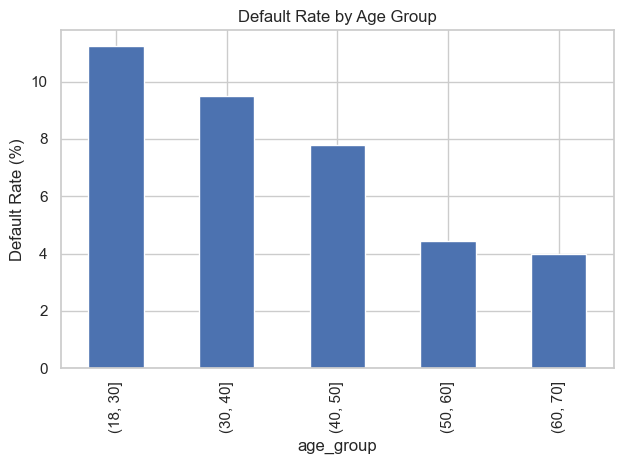

In [32]:
df_train['age_group'] = pd.cut(
    df_train['age'],
    bins=[18,30,40,50,60,70]
)

age_default = pd.crosstab(
    df_train['age_group'],
    df_train['default'],
    normalize='index'
) * 100

age_default[1].plot(kind='bar')
plt.title('Default Rate by Age Group')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.savefig("age-group.png", dpi=300, bbox_inches="tight")  # PNG, 300 DPI
plt.show()


**Insights**

1. Average age in the default group is little less (37.12) than the average (39.7) of the group that did not default
1. Variability (standard deviation) is mostly similar in both the groups
1. Both the groups have similar min and max ages

### KDE for all the Columns

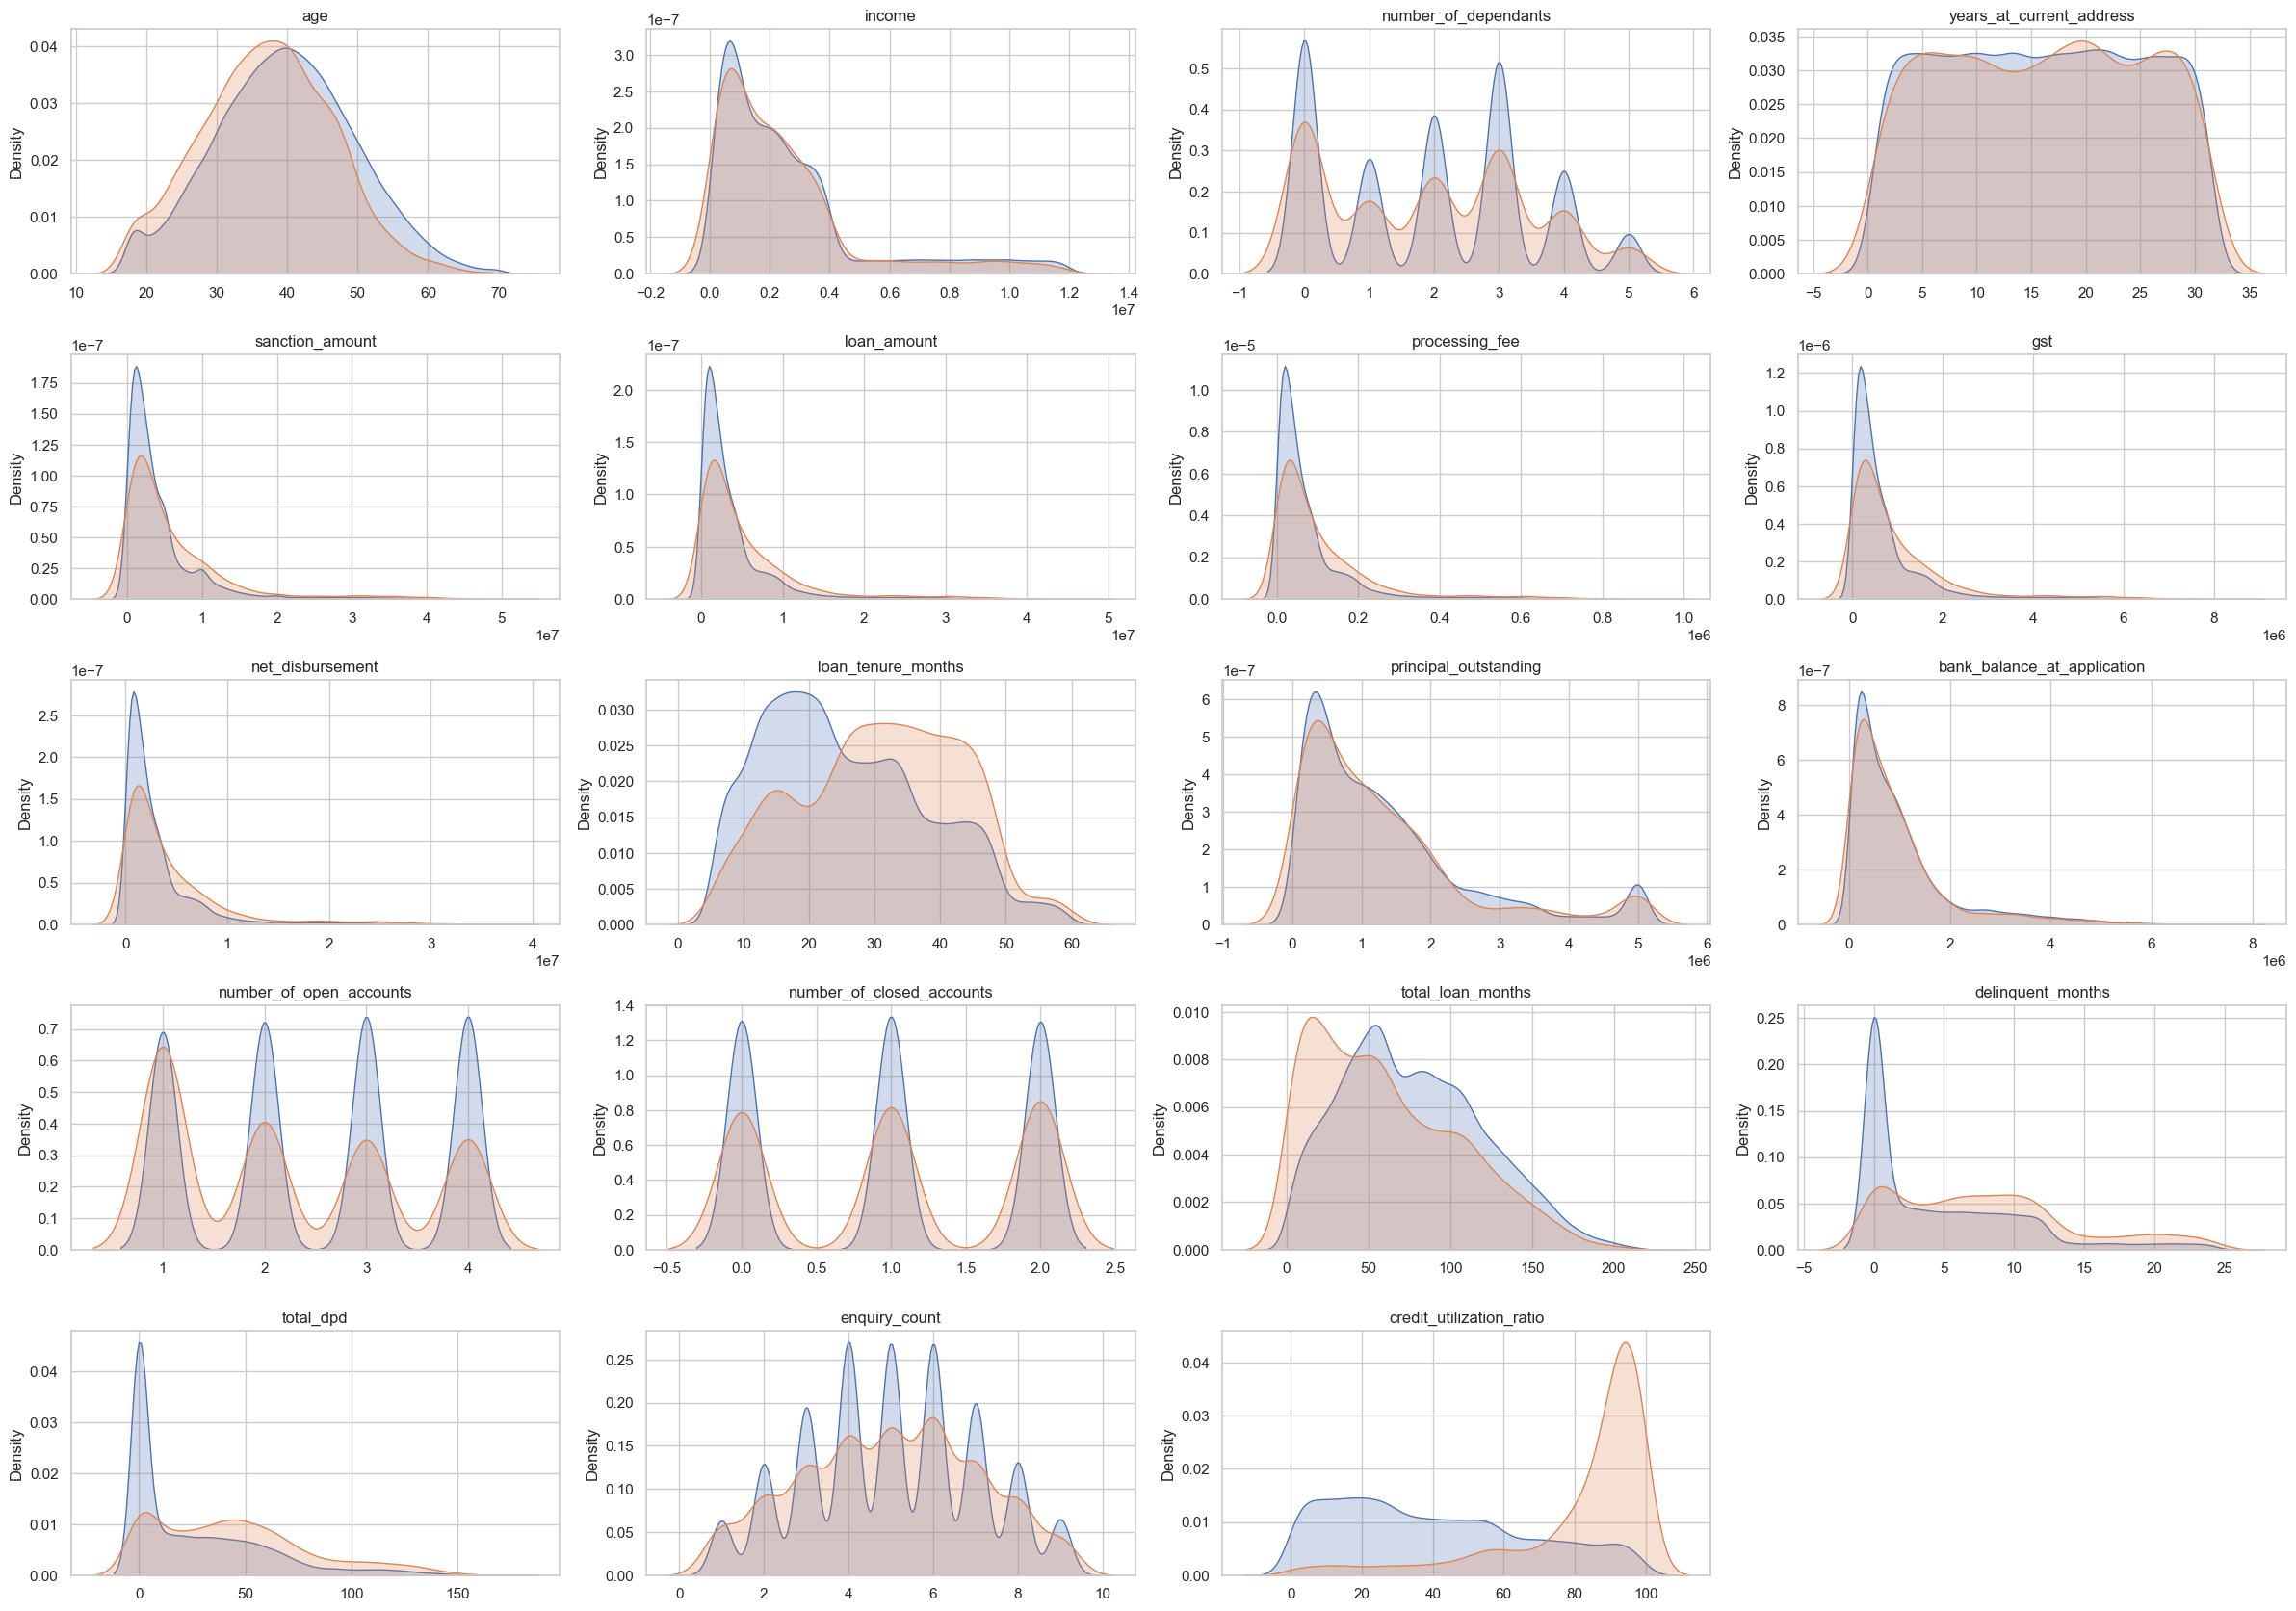

In [33]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train[col][df_train['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train[col][df_train['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.savefig("kdeplots_default.png", dpi=300, bbox_inches='tight')
plt.show()

**Insights**
1. Orange (defaulted) group is slightly shifted to left indicating that younger persons are more likely to default on their loans
2. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 looks like strong predictors
3. In remaining columns the distributions do not give any obvious insights
4. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

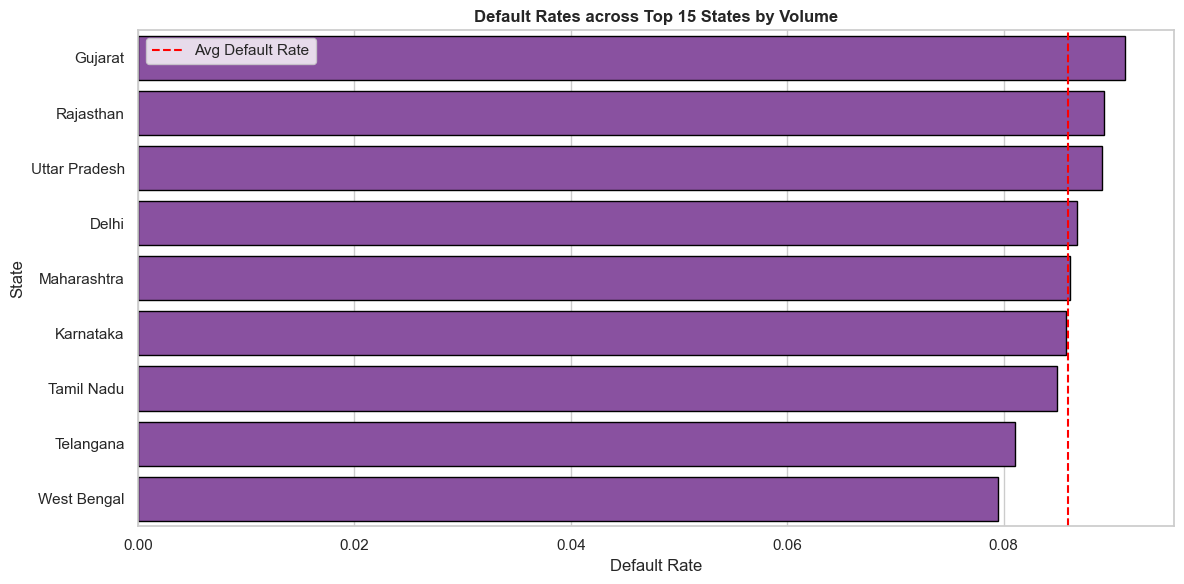

In [34]:
state_risk = df_train.groupby('state')['default'].agg(['mean', 'count']).reset_index()

# Filter states with high volume to focus on significant patterns
top_states = state_risk.sort_values(by='count', ascending=False).head(15)
top_states = top_states.sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x='mean', y='state', color='#8e44ad', edgecolor='black')
plt.axvline(x=df_train['default'].mean(), color='red', linestyle='--', label='Avg Default Rate')
plt.title('Default Rates across Top 15 States by Volume', weight='bold')
plt.xlabel('Default Rate')
plt.ylabel('State')
plt.legend()
plt.tight_layout()
plt.savefig("state_wise_default.png", dpi=300, bbox_inches="tight")  # PNG, 300 DPI
plt.show()

<h3 style="color:blue" align="center">Feature Engineering, Feature Selection</h3>

#### Generate Features

In [35]:
for df in [df_train, df_test]:    
    df['delinquency_ratio'] = (df['delinquent_months']*100 / df['total_loan_months']).round(1)
    df['monthly_installment'] = df['loan_amount'] / df['loan_tenure_months']        
    df['loan_to_income'] = round(df['loan_amount'] / df['income'],2)

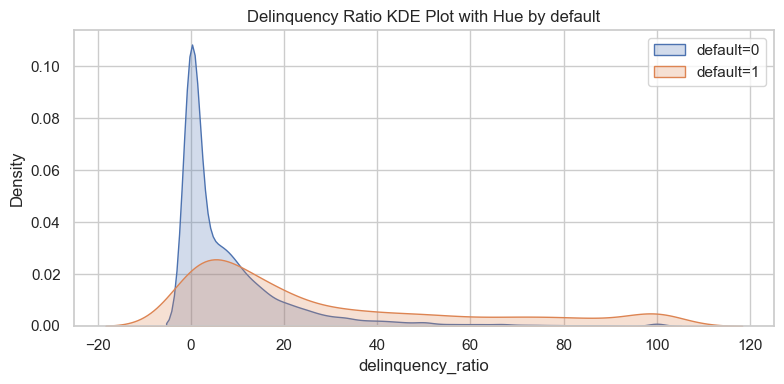

In [36]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['delinquency_ratio'][df_train['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train['delinquency_ratio'][df_train['default'] == 1], fill=True, label='default=1')
plt.title(f"Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.tight_layout()
plt.savefig('delinquency_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

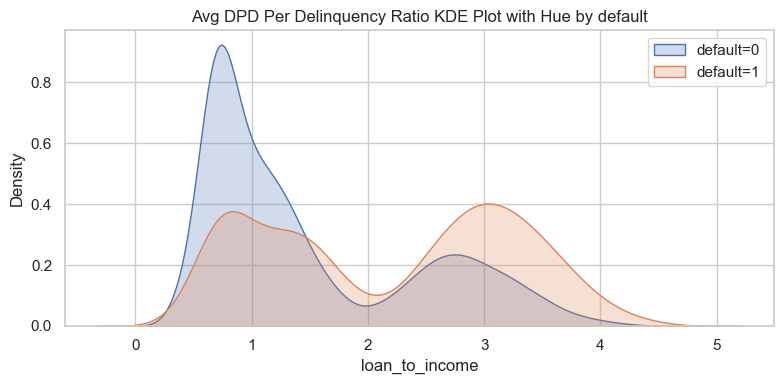

In [37]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['loan_to_income'][df_train['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train['loan_to_income'][df_train['default'] == 1], fill=True, label='default=1')
plt.title(f"Avg DPD Per Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.tight_layout()
plt.savefig('delinquency_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

### Remove columns that are just unique ids and don't have influence on target

In [38]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'age_group', 'delinquency_ratio', 'monthly_installment',
       'loan_to_income'],
      dtype='object')

In [39]:
df_train_2 = df_train.drop(['cust_id', 'loan_id','age_group'],axis="columns")
df_test = df_test.drop(['cust_id', 'loan_id'],axis="columns")

In [40]:
df_train_3 = df_train_2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
                              
df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'delinquency_ratio',
       'monthly_installment', 'loan_to_income'],
      dtype='object')

In [41]:
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'delinquency_ratio', 'monthly_installment',
       'loan_to_income'],
      dtype='object')

### VIF to measure multicolinearity

#### Feature Scaling

Feature Scaling is the process of bringing all features to a similar range so that no single feature dominates the model because of its larger values.

Min-Max Scaling transforms feature values into a range between **0 and 1**.

##### Example
If a feature contains values from 20 to 100:
- 20 → 0
- 60 → 0.5
- 100 → 1

In [42]:
df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  int64  
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  int64  
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  int64  
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  int64  
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  sanction_amount              37488 non-null  int64  
 13  processing_fee   

In [43]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 12746 to 37784
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37500 non-null  object 
 1   age                          37500 non-null  int64  
 2   gender                       37500 non-null  object 
 3   marital_status               37500 non-null  object 
 4   employment_status            37500 non-null  object 
 5   income                       37500 non-null  int64  
 6   number_of_dependants         37500 non-null  int64  
 7   residence_type               37453 non-null  object 
 8   years_at_current_address     37500 non-null  int64  
 9   city                         37500 non-null  object 
 10  state                        37500 non-null  object 
 11  zipcode                      37500 non-null  int64  
 12  loan_id                      37500 non-null  object 
 13  loan_purpose     

In [44]:
X_train = df_train_3.drop('default', axis='columns')
y_train = df_train_3['default']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = X_train.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,delinquency_ratio,monthly_installment,loan_to_income
count,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.10,0.10,0.29
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.17,0.11,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.00,0.03,0.11
50%,0.40,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.67,0.50,0.50,0.39,0.04,0.06,0.20
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.62,0.68,0.13,0.13,0.51
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


#### Same transformation on test set

In [45]:
X_test = df_test.drop('default', axis='columns')
y_test = df_test['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,delinquency_ratio,monthly_installment,loan_to_income
count,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00
mean,0.42,0.38,0.50,0.53,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.11,0.10,0.29
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.25,0.13,0.37,0.41,0.25,0.30,0.17,0.11,0.23
min,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.00,0.03,0.11
50%,0.42,0.40,0.50,0.51,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.33,0.50,0.50,0.39,0.04,0.06,0.20
75%,0.54,0.60,0.77,0.76,0.10,0.09,0.09,0.09,0.55,0.36,0.16,0.67,1.00,0.62,0.68,0.13,0.13,0.50
max,1.00,1.00,1.00,1.00,0.98,0.96,0.96,0.96,1.00,1.00,0.94,1.00,1.00,1.00,1.00,1.00,1.05,1.00


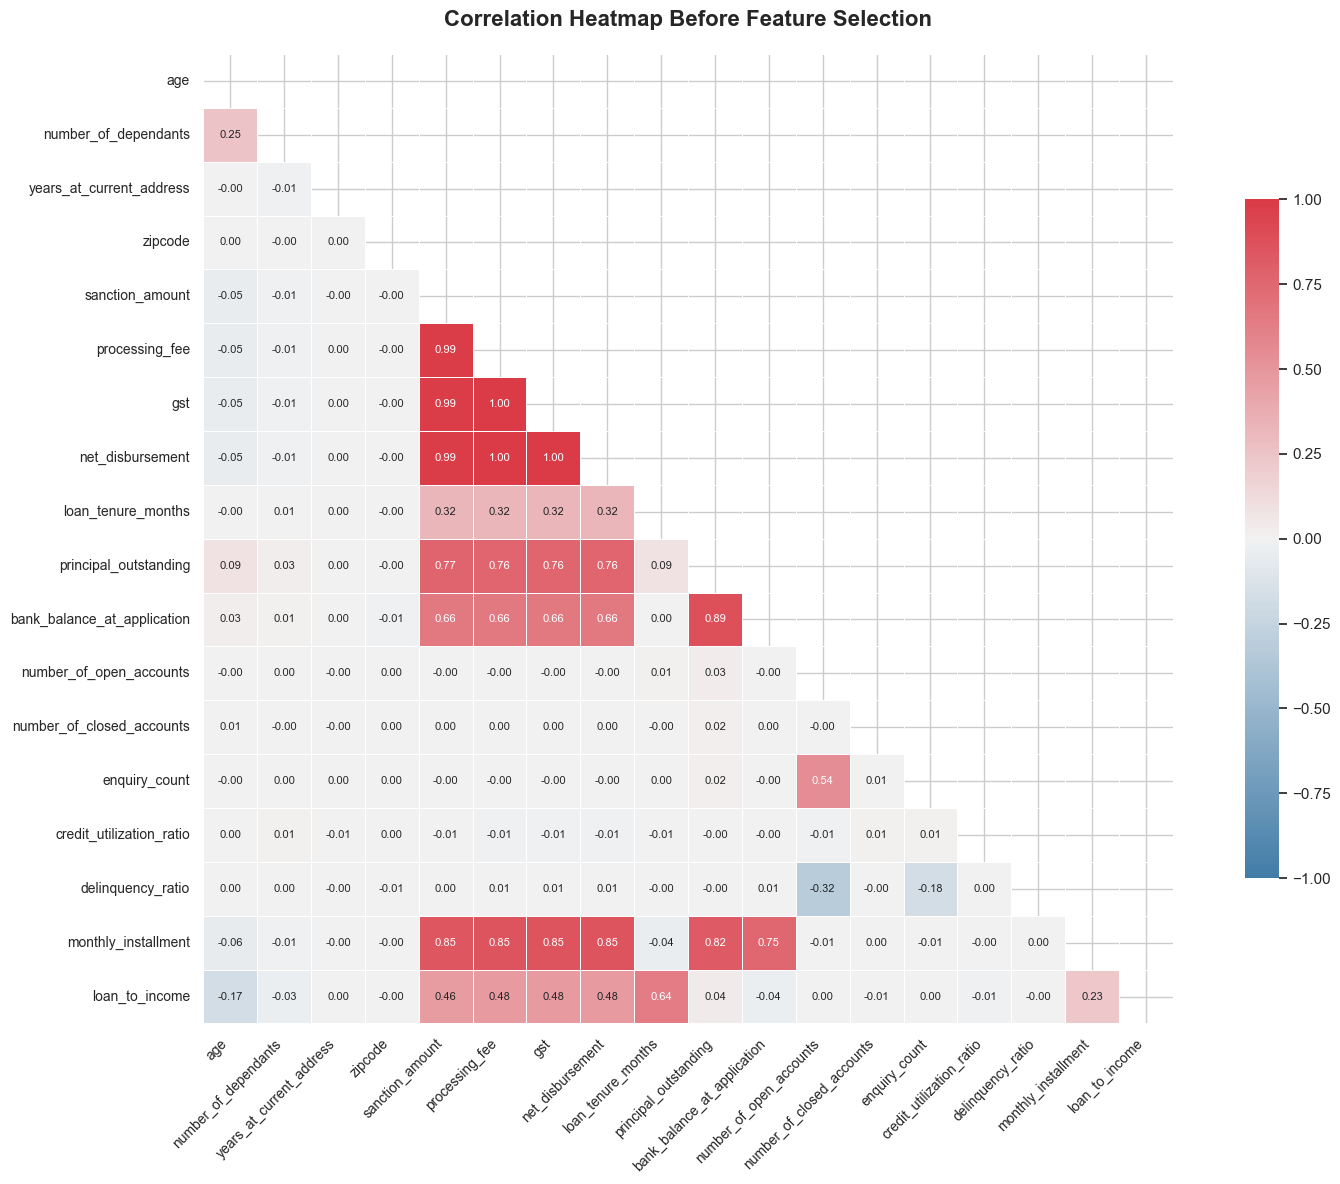

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute correlation matrix using specified training columns
corr_matrix = df_train[cols_to_scale].corr()

# 2. Setup the matplotlib figure with extra width
plt.figure(figsize=(16, 12))

# 3. Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Generate a clean diverging colormap
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# 5. Draw the clean, non-overlapping heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=True,              
    fmt='.2f',               # Restricts numbers to 2 decimal places
    annot_kws={"size": 8},   # Shrinks inner text size to prevent overlapping
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .7}  
)

# 6. Adjust label rotations for perfect scannability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# 7. Add title and clean up layout
plt.title('Correlation Heatmap Before Feature Selection', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("corr_before.png", dpi=300, bbox_inches="tight")

# 8. Show the plot
plt.show()


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [48]:
X_train.head(2)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,delinquency_ratio,monthly_installment,loan_to_income
12746,0.79,M,Married,Self-Employed,0.60,Owned,0.97,Hyderabad,Telangana,0.66,...,0.42,1.00,0.61,1.00,1.00,0.38,0.36,0.13,0.52,0.41
32495,0.50,F,Single,Salaried,0.00,Owned,0.87,Mumbai,Maharashtra,0.49,...,0.83,0.09,0.03,0.67,0.50,0.50,0.05,0.06,0.01,0.31


In [49]:
calculate_vif(X_train[cols_to_scale])

,Column,VIF
0,age,5.68
1,number_of_dependants,2.73
2,years_at_current_address,3.44
3,zipcode,3.83
4,sanction_amount,101.27
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,9.90
9,principal_outstanding,18.16


In [50]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
                        'loan_tenure_months','bank_balance_at_application','enquiry_count','principal_outstanding'
                       ]

X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'credit_utilization_ratio', 'delinquency_ratio', 'monthly_installment',
       'loan_to_income'],
      dtype='object')

In [51]:
calculate_vif(X_train[numeric_columns])

,Column,VIF
0,age,5.01
1,number_of_dependants,2.72
2,years_at_current_address,3.33
3,zipcode,3.70
4,number_of_open_accounts,2.75
5,number_of_closed_accounts,2.35
6,credit_utilization_ratio,2.87
7,delinquency_ratio,1.43
8,monthly_installment,1.86
9,loan_to_income,2.61


In [52]:
selected_features = calculate_vif(X_train_1[numeric_columns])

In [53]:
selected_numeric_features_vif = selected_features.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'credit_utilization_ratio', 'delinquency_ratio',
       'monthly_installment', 'loan_to_income'], dtype=object)

In [54]:
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'credit_utilization_ratio', 'delinquency_ratio', 'monthly_installment',
       'loan_to_income'],
      dtype='object')

In [55]:
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'credit_utilization_ratio', 'delinquency_ratio', 'monthly_installment',
       'loan_to_income'],
      dtype='object')

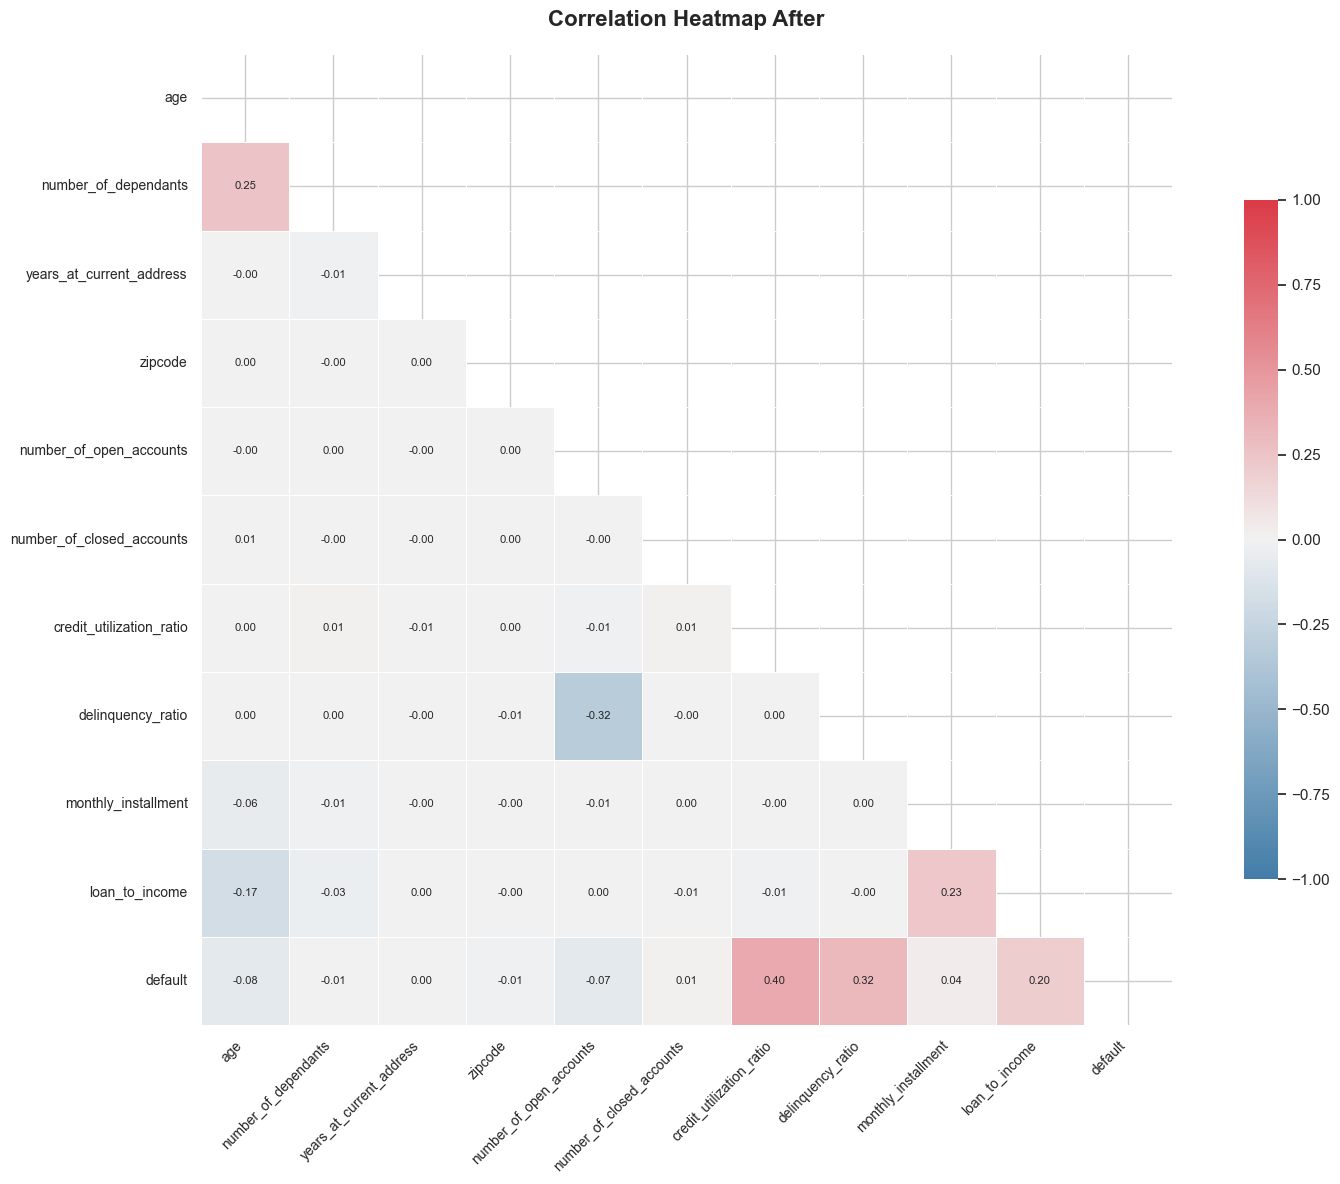

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Compute correlation matrix using specified training columns
cm = df_train_3[numeric_columns.append(pd.Index(['default']))].corr()

# 2. Setup the matplotlib figure with extra width
plt.figure(figsize=(16, 12))

# 3. Create a mask for the upper triangle
mask = np.triu(np.ones_like(cm, dtype=bool))

# 4. Generate a clean diverging colormap
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# 5. Draw the clean, non-overlapping heatmap
sns.heatmap(
    cm,  # Use the correct variable name here
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',               # Restricts numbers to 2 decimal places
    annot_kws={"size": 8},   # Shrinks inner text size to prevent overlapping
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

# 6. Adjust label rotations for perfect scannability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# 7. Add title and clean up layout
plt.title('Correlation Heatmap After', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("corr_after1.png", dpi=300, bbox_inches="tight")

# 8. Show the plot
plt.show()


### Feature Selection: Categorical Features

In [57]:
X_train_1.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_purpose,loan_type,number_of_open_accounts,number_of_closed_accounts,credit_utilization_ratio,delinquency_ratio,monthly_installment,loan_to_income
12746,0.79,M,Married,Self-Employed,0.60,Owned,0.97,Hyderabad,Telangana,0.66,Home,Secured,1.00,1.00,0.36,0.13,0.52,0.41
32495,0.50,F,Single,Salaried,0.00,Owned,0.87,Mumbai,Maharashtra,0.49,Education,Secured,0.67,0.50,0.05,0.06,0.01,0.31
43675,0.38,M,Single,Salaried,0.00,Mortgage,0.83,Chennai,Tamil Nadu,0.83,Home,Secured,0.00,0.50,0.00,0.22,0.22,0.76
9040,0.46,M,Married,Salaried,0.40,Mortgage,0.97,Bangalore,Karnataka,0.76,Education,Secured,0.67,0.00,0.88,0.00,0.02,0.19
13077,0.77,M,Married,Self-Employed,0.80,Owned,0.93,Pune,Maharashtra,0.51,Personal,Unsecured,0.00,1.00,0.72,0.00,0.04,0.05


#### Calculate WOE and IV 

WOE is a technique used to convert categorical or numerical variables into values that show how strongly they are related to the target variable (default or non-default).

##### Why It Is Used

- Handles categorical variables effectively
- Makes the relationship with default risk easier to understand
- Widely used in credit risk modeling
- Improves model interpretability

**Higher positive WOE** → Lower risk of default  
**Higher negative WOE** → Higher risk of default

In [58]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,0.08
Education,5620,559,5061,0.17,0.15,0.16,0.00
Home,11304,1734,9570,0.54,0.28,0.66,0.17
Personal,13117,603,12514,0.19,0.37,-0.67,0.12


In [59]:
X_train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        37488 non-null  float64
 1   gender                     37488 non-null  object 
 2   marital_status             37488 non-null  object 
 3   employment_status          37488 non-null  object 
 4   number_of_dependants       37488 non-null  float64
 5   residence_type             37488 non-null  object 
 6   years_at_current_address   37488 non-null  float64
 7   city                       37488 non-null  object 
 8   state                      37488 non-null  object 
 9   zipcode                    37488 non-null  float64
 10  loan_purpose               37488 non-null  object 
 11  loan_type                  37488 non-null  object 
 12  number_of_open_accounts    37488 non-null  float64
 13  number_of_closed_accounts  37488 non-null  floa

In [60]:
iv_values = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), feature, 'default' )
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train],axis=1), feature, 'default' )
    iv_values[feature] = iv
        
iv_values

{'age': 0.0890689462679479,
 'gender': 0.00047449502170914947,
 'marital_status': 0.001129766845390142,
 'employment_status': 0.003953046301722585,
 'number_of_dependants': 0.0019380899135053508,
 'residence_type': 0.246745268718145,
 'years_at_current_address': 0.0020800513608156363,
 'city': 0.0019059578709781529,
 'state': 0.0019005589806779287,
 'zipcode': 0.0016677413243392572,
 'loan_purpose': 0.3691197842282755,
 'loan_type': 0.16319324904149224,
 'number_of_open_accounts': 0.08463134083005877,
 'number_of_closed_accounts': 0.0011964272592421567,
 'credit_utilization_ratio': 2.352965568168245,
 'delinquency_ratio': 0.716576108689321,
 'monthly_installment': 0.024056393241648703,
 'loan_to_income': 0.476415456948364}

In [61]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df


,Feature,IV
14,credit_utilization_ratio,2.353
15,delinquency_ratio,0.717
17,loan_to_income,0.476
10,loan_purpose,0.369
5,residence_type,0.247
11,loan_type,0.163
0,age,0.089
12,number_of_open_accounts,0.085
16,monthly_installment,0.024
3,employment_status,0.004


In [62]:
df.number_of_open_accounts.value_counts()

number_of_open_accounts
1    3149
2    3147
3    3106
4    3095
Name: count, dtype: int64

In [63]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'delinquency_ratio',
 'monthly_installment',
 'loan_to_income']

### Feature Encoding

In [64]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [65]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded.head(3)

,age,number_of_open_accounts,credit_utilization_ratio,delinquency_ratio,monthly_installment,loan_to_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.788,1.000,0.364,0.132,0.515,0.415,True,False,False,True,False,False
32495,0.500,0.667,0.051,0.062,0.013,0.307,True,False,True,False,False,False
43675,0.385,0.000,0.000,0.222,0.216,0.759,False,False,False,True,False,False


In [66]:
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True) #Applied One-Hot-Encoding
X_test_encoded.head(3)

,age,number_of_open_accounts,credit_utilization_ratio,delinquency_ratio,monthly_installment,loan_to_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.333,0.990,0.000,0.131,0.550,True,False,False,True,False,False
15514,0.481,1.000,0.323,0.000,0.104,0.220,True,False,True,False,False,False
30367,0.231,0.667,0.828,0.000,0.057,0.180,True,False,False,False,False,False


<h2 align="center" style="color:blue">Model Training</h2>

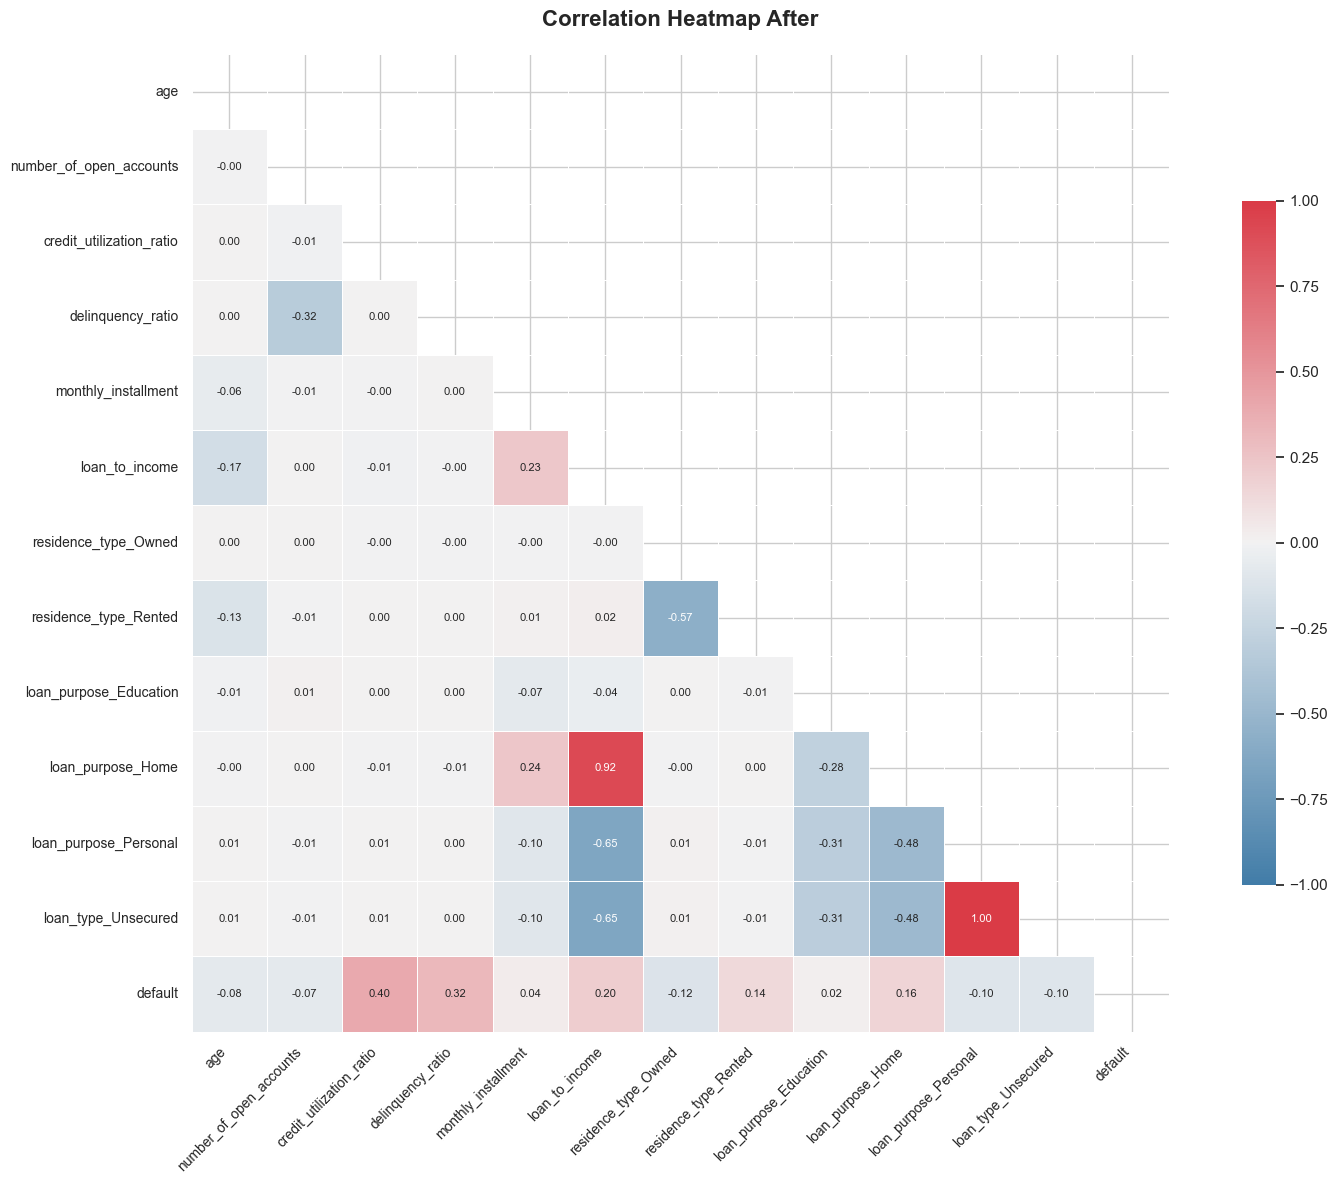

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Combine X_train_encoded with target column 'default'
cm = pd.concat([X_train_encoded, y_train.rename("default")], axis=1).corr()

# 2. Setup the matplotlib figure with extra width
plt.figure(figsize=(16, 12))

# 3. Create a mask for the upper triangle
mask = np.triu(np.ones_like(cm, dtype=bool))

# 4. Generate a clean diverging colormap
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# 5. Draw the clean, non-overlapping heatmap
sns.heatmap(
    cm,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',               # Restricts numbers to 2 decimal places
    annot_kws={"size": 8},   # Shrinks inner text size to prevent overlapping
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

# 6. Adjust label rotations for perfect scannability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# 7. Add title and clean up layout
plt.title('Correlation Heatmap After', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("corr_with_default_final.png", dpi=300, bbox_inches="tight")

# 8. Show the plot
plt.show()


In [68]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       37488 non-null  float64
 1   number_of_open_accounts   37488 non-null  float64
 2   credit_utilization_ratio  37488 non-null  float64
 3   delinquency_ratio         37488 non-null  float64
 4   monthly_installment       37488 non-null  float64
 5   loan_to_income            37488 non-null  float64
 6   residence_type_Owned      37488 non-null  bool   
 7   residence_type_Rented     37488 non-null  bool   
 8   loan_purpose_Education    37488 non-null  bool   
 9   loan_purpose_Home         37488 non-null  bool   
 10  loan_purpose_Personal     37488 non-null  bool   
 11  loan_type_Unsecured       37488 non-null  bool   
dtypes: bool(6), float64(6)
memory usage: 2.2 MB


In [69]:
from sklearn.metrics import classification_report

def generate_classification_report(model, X_test, y_test):
    
    # Predict labels
    y_pred = model.predict(X_test)

    # Generate report
    report = classification_report(y_test, y_pred)

    # Print nicely
    print("📊 Classification Report:\n")
    print(report)

### Attempt 1

1. Logistic Regression, RandomForest & XGB
1. No handling of class imbalance

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)
generate_classification_report(model, X_test_encoded, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.84      0.70      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.87     12497
weighted avg       0.96      0.96      0.96     12497



In [71]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)
generate_classification_report(model, X_test_encoded, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.86      0.70      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.92      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [72]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train_encoded, y_train)
generate_classification_report(model, X_test_encoded, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.81      0.76      0.79      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.96      0.96     12497



### Attempt 2

1. Logistic Regression & XGB
1. Handle Class Imbalance Using Under Sampling

In [73]:
df_train['default'].value_counts()

default
0    34265
1     3223
Name: count, dtype: int64

In [74]:
y_train.value_counts()

default
0    34265
1     3223
Name: count, dtype: int64

In [75]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_encoded, y_train)

In [76]:
y_train_res.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [77]:
model = LogisticRegression()
model.fit(X_train_res, y_train_res)
generate_classification_report(model, X_test_encoded, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.95     11423
           1       0.52      0.96      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.94      0.81     12497
weighted avg       0.95      0.92      0.93     12497



In [78]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_res, y_train_res)
generate_classification_report(model, X_test_encoded, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11423
           1       0.54      0.97      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.95      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [79]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train_res, y_train_res)
generate_classification_report(model, X_test_encoded, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11423
           1       0.56      0.96      0.71      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.84     12497
weighted avg       0.96      0.93      0.94     12497



### Attempt 3

1. Logistic Regression
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using Randomized Search CV

In [80]:
import optuna
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import make_scorer, fbeta_score, classification_report, f1_score,precision_score,recall_score

In [81]:
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)

In [82]:
y_train_smt.value_counts()

default
0    34173
1    34173
Name: count, dtype: int64

In [83]:
# Define parameter distribution for Logistic Regression
param_dist = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': np.logspace(-3, 3, 20),   # inverse regularization strength
    'solver': ['saga'],            # saga supports l1, l2, elasticnet, none
    'l1_ratio': np.linspace(0, 1, 10)  # only used if penalty='elasticnet'
}

# Base model
log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,              # reduce if runtime is long
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit search on training data
random_search.fit(X_train_smt, y_train_smt)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': array([ 0.0...000. ]), 'l1_ratio': array([0. ..., 1. ]), 'penalty': ['l1', 'l2', ...], 'solver': ['saga']}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [84]:
# Print best parameters and score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV F1 Score: {random_search.best_score_:.4f}")

# Retrieve best model
lr_model = random_search.best_estimator_

# Train best model on full training set
lr_model.fit(X_train_smt, y_train_smt)

y_pred = lr_model.predict(X_test_encoded)

# Evaluate on test set
report = classification_report(y_test,y_pred)
print(report)

Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.0, 'C': 0.6951927961775606}
Best CV F1 Score: 0.9450
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.95      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [85]:
# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train_smt, y_train_smt)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...], ...}"
,n_iter,100
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [86]:
# Print best parameters and score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV F1 Score: {random_search.best_score_:.4f}")

# Retrieve best model
xgb_model = random_search.best_estimator_

# Train best model on full training set
xgb_model.fit(X_train_smt, y_train_smt)

# Evaluate on test set
y_pred = xgb_model.predict(X_test_encoded)
generate_classification_report(xgb_model, X_test_encoded, y_test)

Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 1, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.25, 'colsample_bytree': 0.8}
Best CV F1 Score: 0.9773
📊 Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11423
           1       0.73      0.83      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.86      0.90      0.88     12497
weighted avg       0.96      0.96      0.96     12497



### OPTUNA

In [87]:

# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-06-26 23:19:18,193] A new study created in memory with name: no-name-8012ee4e-e7de-4c57-911a-c5056a52ad99
[I 2026-06-26 23:19:18,434] Trial 0 finished with value: 0.9435408262386774 and parameters: {'C': 9.015153902187489, 'solver': 'newton-cg', 'tol': 0.001911714544947884, 'class_weight': None}. Best is trial 0 with value: 0.9435408262386774.
[I 2026-06-26 23:19:18,589] Trial 1 finished with value: 0.783802324634897 and parameters: {'C': 0.00010291284152444153, 'solver': 'liblinear', 'tol': 0.04374555747978717, 'class_weight': None}. Best is trial 0 with value: 0.9435408262386774.
[I 2026-06-26 23:19:18,871] Trial 2 finished with value: 0.9426890967522503 and parameters: {'C': 0.31313832942819564, 'solver': 'newton-cg', 'tol': 2.7543192140017557e-05, 'class_weight': None}. Best is trial 0 with value: 0.9435408262386774.
[I 2026-06-26 23:19:19,136] Trial 3 finished with value: 0.9439009171469211 and parameters: {'C': 404.8807826255259, 'solver': 'newton-cg', 'tol': 1.9365528588

In [88]:
print("Optuna Best Hyperparameter")
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)


Optuna Best Hyperparameter
Best trial:
  F1-score: 0.9440591560086036
  Params: 
    C: 2.9187777301263873
    solver: liblinear
    tol: 0.004271688343347554
    class_weight: None


,penalty,'l2'
,dual,False
,tol,0.004271688343347554
,C,2.9187777301263873
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [89]:
# 4. Evaluate on Test Set
y_pred_lr = best_model_logistic.predict(X_test_encoded)
print("\n--- Logistic Regression Final Test Report ---")
print(classification_report(y_test, y_pred_lr))


--- Logistic Regression Final Test Report ---
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.95      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



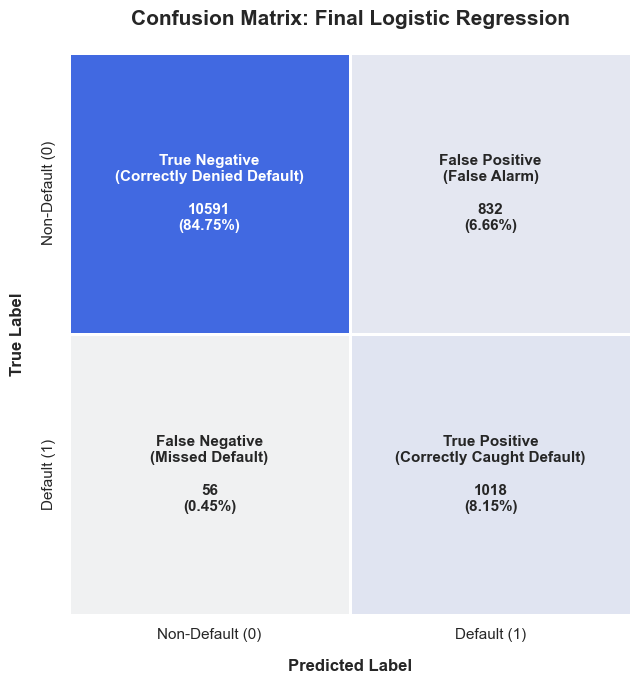

In [90]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

# 2. Create detailed cell labels (Name, Count, Percentage)
group_names = [
    'True Negative\n(Correctly Denied Default)', 
    'False Positive\n(False Alarm)', 
    'False Negative\n(Missed Default)', 
    'True Positive\n(Correctly Caught Default)'
]
group_counts = [f"{value:d}" for value in cm.flatten()]
group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]

labels = [f"{v1}\n\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

# 3. Set up a square figure size and clean white theme
plt.figure(figsize=(7, 7))  # Perfect square canvas
sns.set_theme(style="white")

# 4. Draw the confusion matrix heatmap
sns.heatmap(
    cm, 
    annot=labels, 
    fmt="",                      # Using custom string labels
    cmap=sns.light_palette("royalblue", as_cmap=True), # Soft professional blue
    square=True,                 # Force cells to be square
    linewidths=2,                # White borders to separate cells
    linecolor='white',
    cbar=False,                  # Remove the sidebar (colorbar)
    xticklabels=['Non-Default (0)', 'Default (1)'],
    yticklabels=['Non-Default (0)', 'Default (1)'],
    annot_kws={"size": 11, "weight": "bold"}  # Styling text inside cells
)

# 5. Format labels and title
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=12)
plt.title('Confusion Matrix: Final Logistic Regression', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("lr_model_confu.png", dpi=300, bbox_inches="tight")

plt.show()

In [91]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Define objective function for XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        # Helper parameter for class imbalance
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42
    }
    
    model = XGBClassifier(**params)
    
    # 3-Fold Cross Validation optimizing F2-Score
    f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f2_scorer, n_jobs=-1)
    return np.mean(scores)

# 2. Run XGBoost tuning
print("Tuning XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30)

Tuning XGBoost...


In [92]:
# 3. Train final model with best parameters
print("Best XGBoost Params:")
print(study_xgb.best_params)
best_model_xgb = XGBClassifier(**study_xgb.best_params, random_state=42)
best_model_xgb.fit(X_train_smt, y_train_smt)

Best XGBoost Params:
{'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.04418139690799277, 'subsample': 0.9013932441790297, 'colsample_bytree': 0.8836437969805622, 'gamma': 0.2544367645816331, 'scale_pos_weight': 4.785122575827831}


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8836437969805622
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [93]:
# 4. Evaluate on Test Set
y_pred_xgb = best_model_xgb.predict(X_test_encoded)
print("\n--- XGBoost Final Test Report ---")
print(classification_report(y_test, y_pred_xgb))


--- XGBoost Final Test Report ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     11423
           1       0.69      0.88      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.84      0.92      0.87     12497
weighted avg       0.96      0.96      0.96     12497



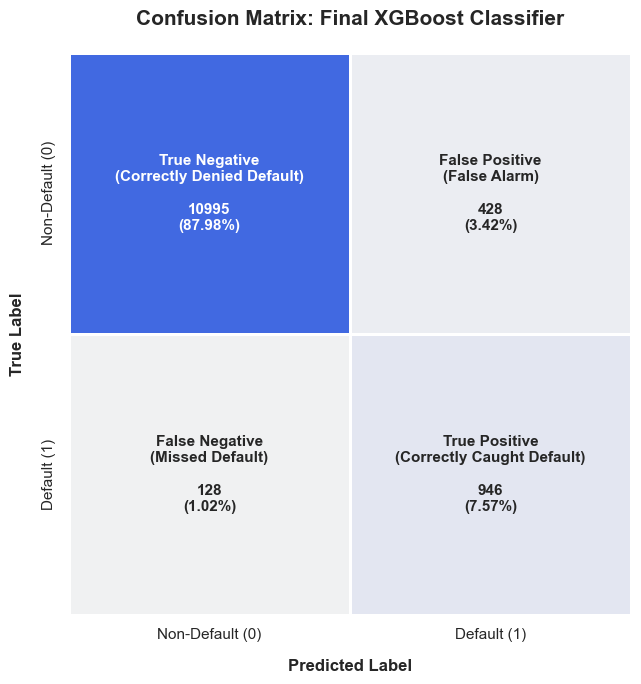

In [94]:
# 1. Compute the confusion matrix using your custom 0.35 threshold predictions
cm = confusion_matrix(y_test, y_pred_xgb)

# 2. Create detailed cell labels (Name, Count, Percentage)
group_names = [
    'True Negative\n(Correctly Denied Default)', 
    'False Positive\n(False Alarm)', 
    'False Negative\n(Missed Default)', 
    'True Positive\n(Correctly Caught Default)'
]
group_counts = [f"{value:d}" for value in cm.flatten()]
group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]

labels = [f"{v1}\n\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

# 3. Set up a square figure size and clean white theme
plt.figure(figsize=(7, 7))  # Perfect square canvas
sns.set_theme(style="white")

# 4. Draw the confusion matrix heatmap
sns.heatmap(
    cm, 
    annot=labels, 
    fmt="",                      # Using custom string labels
    cmap=sns.light_palette("royalblue", as_cmap=True), # Soft professional blue
    square=True,                 # Force cells to be square
    linewidths=2,                # White borders to separate cells
    linecolor='white',
    cbar=False,                  # Remove the sidebar (colorbar)
    xticklabels=['Non-Default (0)', 'Default (1)'],
    yticklabels=['Non-Default (0)', 'Default (1)'],
    annot_kws={"size": 11, "weight": "bold"}  # Styling text inside cells
)

# 5. Format labels and title
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=12)
plt.title('Confusion Matrix: Final XGBoost Classifier', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()

# 6. Save the plot as a high-quality PNG
plt.savefig("xgb_model_confu.png", dpi=300, bbox_inches="tight")

# 7. Display the plot
plt.show()

In [122]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Define the objective function for Balanced Random Forest
def objective_brf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200, step=10),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'sampling_strategy': trial.suggest_categorical('sampling_strategy', ['auto', 'all', 'majority']),
        'bootstrap': True,
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = BalancedRandomForestClassifier(**params)
    
    # Optimize for F2-Score to prioritize recall on class 1
    f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)
    
    # USE YOUR ORIGINAL (NON-SMOTE) ENCODED TRAINING DATA HERE
    # (e.g., X_train_encoded, y_train)
    scores = cross_val_score(model, X_train_encoded, y_train, cv=3, scoring=f2_scorer, n_jobs=-1)
    return np.mean(scores)

# 2. Run the Optuna study
print("Tuning Balanced Random Forest...")
study_brf = optuna.create_study(direction='maximize')
study_brf.optimize(objective_brf, n_trials=30)


print("Best Params:")
print(study_brf.best_params)
    

Tuning Balanced Random Forest...
Best Params:
{'n_estimators': 180, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'sampling_strategy': 'all'}


In [123]:
print("Best Params:")
print(study_brf.best_params)

# Trained the final model on the original (non-SMOTE) encoded training data
best_model_brf = BalancedRandomForestClassifier(**study_brf.best_params, random_state=42, n_jobs=-1)
best_model_brf.fit(X_train_encoded, y_train)

Best Params:
{'n_estimators': 180, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'sampling_strategy': 'all'}


,n_estimators,180
,criterion,'gini'
,max_depth,17
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [124]:
# Evaluate on the Test Set
y_pred_brf = best_model_brf.predict(X_test_encoded)
print("\n--- Balanced Random Forest Final Test Report ---")
print(classification_report(y_test, y_pred_brf, digits = 3))


--- Balanced Random Forest Final Test Report ---
              precision    recall  f1-score   support

           0      0.995     0.937     0.966     11423
           1      0.589     0.953     0.728      1074

    accuracy                          0.939     12497
   macro avg      0.792     0.945     0.847     12497
weighted avg      0.960     0.939     0.945     12497



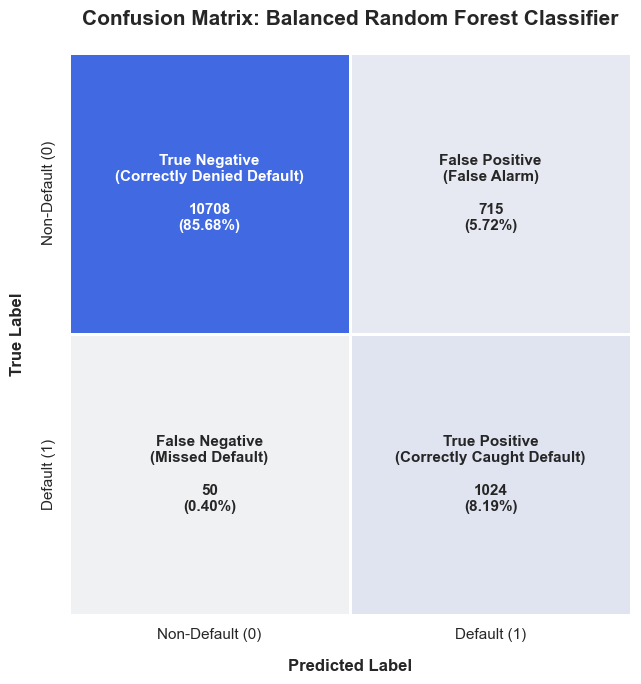

In [125]:
# 1. Compute the confusion matrix using your custom 0.35 threshold predictions
cm = confusion_matrix(y_test, y_pred_brf)

# 2. Create detailed cell labels (Name, Count, Percentage)
group_names = [
    'True Negative\n(Correctly Denied Default)', 
    'False Positive\n(False Alarm)', 
    'False Negative\n(Missed Default)', 
    'True Positive\n(Correctly Caught Default)'
]
group_counts = [f"{value:d}" for value in cm.flatten()]
group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]

labels = [f"{v1}\n\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

# 3. Set up a square figure size and clean white theme
plt.figure(figsize=(7, 7))  # Perfect square canvas
sns.set_theme(style="white")

# 4. Draw the confusion matrix heatmap
sns.heatmap(
    cm, 
    annot=labels, 
    fmt="",                      # Using custom string labels
    cmap=sns.light_palette("royalblue", as_cmap=True), # Soft professional blue
    square=True,                 # Force cells to be square
    linewidths=2,                # White borders to separate cells
    linecolor='white',
    cbar=False,                  # Remove the sidebar (colorbar)
    xticklabels=['Non-Default (0)', 'Default (1)'],
    yticklabels=['Non-Default (0)', 'Default (1)'],
    annot_kws={"size": 11, "weight": "bold"}  # Styling text inside cells
)

# 5. Format labels and title
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=12)
plt.title('Confusion Matrix: Balanced Random Forest Classifier', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()

# 6. Save the plot as a high-quality PNG
plt.savefig("brf_model_confu.png", dpi=300, bbox_inches="tight")

# 7. Display the plot
plt.show()

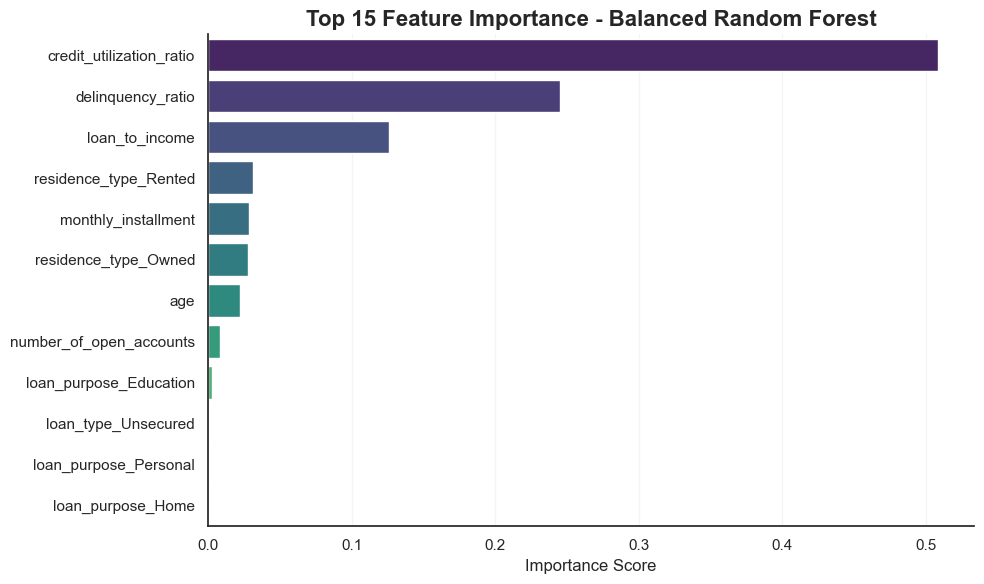

In [126]:
fi = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': best_model_brf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=fi,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 15 Feature Importance - Balanced Random Forest',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Importance Score')
plt.ylabel('')
plt.grid(axis='x', alpha=0.2)

sns.despine()
plt.tight_layout()
plt.savefig("feature-importance.png", dpi=300, bbox_inches="tight")

plt.show()

--- Threshold Tuning Table ---
Threshold  Precision  Recall  F1-Score
     0.20      0.436   0.989     0.605
     0.25      0.463   0.984     0.630
     0.30      0.492   0.983     0.655
     0.35      0.519   0.977     0.678
     0.40      0.542   0.968     0.695
     0.45      0.562   0.963     0.709
     0.50      0.589   0.953     0.728
     0.55      0.610   0.945     0.741
     0.60      0.631   0.927     0.751
     0.65      0.655   0.909     0.761
     0.70      0.680   0.885     0.769


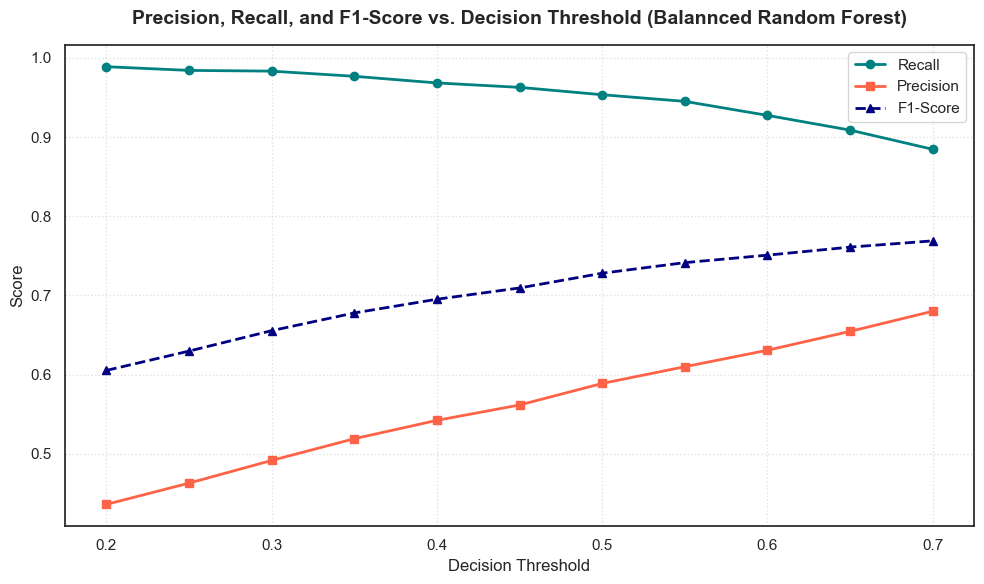

In [127]:
# 1. Get predicted probabilities from your tuned model
y_proba = best_model_brf.predict_proba(X_test_encoded)[:, 1]

# 2. Test thresholds in a reasonable range (0.2 to 0.7)
thresholds = np.arange(0.2, 0.75, 0.05)
precision_list = []
recall_list = []
f1_list = []

for th in thresholds:
    preds = (y_proba >= th).astype(int)
    precision_list.append(precision_score(y_test, preds, pos_label=1))
    recall_list.append(recall_score(y_test, preds, pos_label=1))
    f1_list.append(f1_score(y_test, preds, pos_label=1))

# 3. Create a clean table of the results
df_tuning = pd.DataFrame({
    'Threshold': [f"{th:.2f}" for th in thresholds],
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list
})

print("--- Threshold Tuning Table ---")
print(df_tuning.to_string(index=False))

# 4. Plot the results to visually choose the best threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, recall_list, label='Recall', color='teal', marker='o', linewidth=2)
plt.plot(thresholds, precision_list, label='Precision', color='tomato', marker='s', linewidth=2)
plt.plot(thresholds, f1_list, label='F1-Score', color='navy', linestyle='--', marker='^', linewidth=2)

plt.title('Precision, Recall, and F1-Score vs. Decision Threshold (Balannced Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("thold.png", dpi=300, bbox_inches="tight")

# Save the plot in high quality
plt.show()

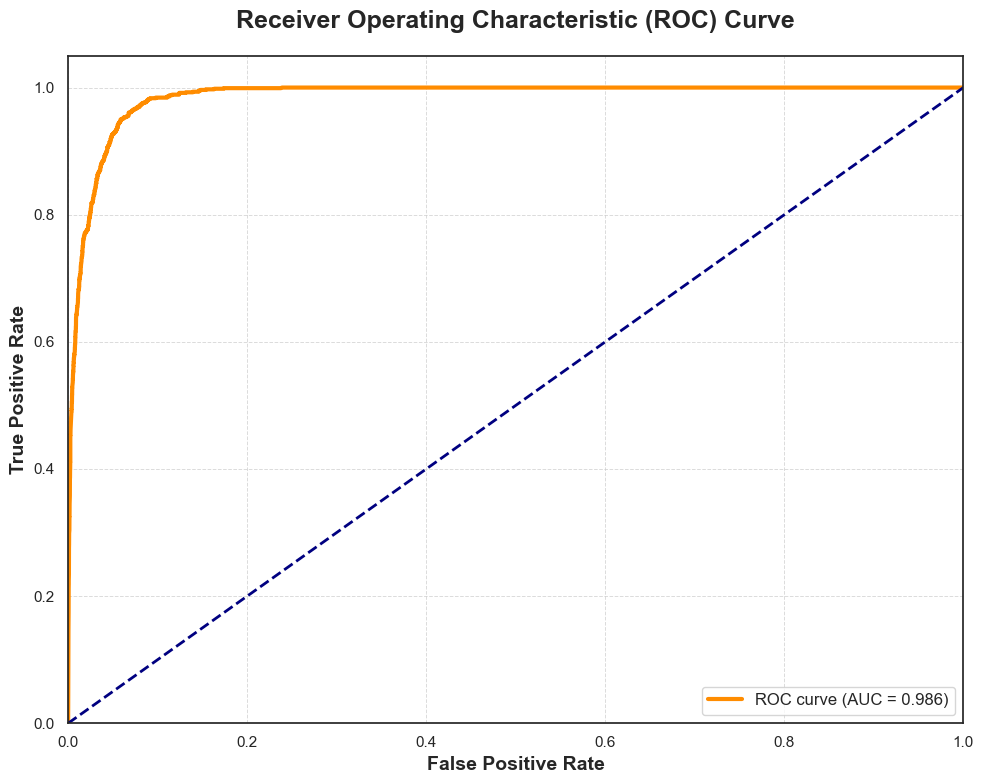

In [128]:
from sklearn.metrics import roc_curve, auc,roc_auc_score

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

#  Set up plot style and size
plt.figure(figsize=(10, 8))

# Plot ROC curve with professional styling
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.3f})')

#  Plot diagonal line for random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

#  Customize plot labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)

# 7. Add grid and tighten layout
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.savefig("roc.png", dpi=300, bbox_inches="tight")

# 8. Show plot
plt.show()


In [129]:
from sklearn.metrics import roc_auc_score

# Predict probabilities
train_pred = best_model_brf.predict_proba(X_train_encoded)[:, 1]
test_pred = best_model_brf.predict_proba(X_test_encoded)[:, 1]

# Compute AUC
train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)

# Compute Gini coefficient
train_gini = 2 * train_auc - 1
test_gini = 2 * test_auc - 1

# Display results
print(f"Train AUC  : {train_auc:.4f}")
print(f"Test AUC   : {test_auc:.4f}")
print(f"Train Gini : {train_gini:.4f}")
print(f"Test Gini  : {test_gini:.4f}")


Train AUC  : 0.9960
Test AUC   : 0.9855
Train Gini : 0.9919
Test Gini  : 0.9710


In [130]:
ks_df = pd.DataFrame({
    'actual': y_test,
    'score': y_proba
})

In [104]:
ks_df['decile'] = pd.qcut(ks_df['score'], 10, labels=False) + 1

In [105]:
ks_table = ks_df.groupby('decile').agg(total=('actual','count'),events=('actual','sum'))

ks_table['non_events'] = (ks_table['total'] - ks_table['events'])

In [106]:
total_events = ks_table['events'].sum()
total_non_events = ks_table['non_events'].sum()

ks_table['event_pct'] = (ks_table['events'] /total_events) * 100

ks_table['non_event_pct'] = (ks_table['non_events'] /total_non_events) * 100

In [107]:
ks_table['cum_event_pct'] = (ks_table['event_pct'].cumsum())

ks_table['cum_non_event_pct'] = (ks_table['non_event_pct'].cumsum())

In [108]:
ks_table['KS'] = abs(ks_table['cum_event_pct'] - ks_table['cum_non_event_pct'])

In [109]:
max_ks = ks_table['KS'].max()

print(f"KS Statistic: {max_ks:.2f}")
ks_table

KS Statistic: 86.80


,total,events,non_events,event_pct,non_event_pct,cum_event_pct,cum_non_event_pct,KS
decile,,,,,,,,
1,1250,0,1250,0.000,10.943,0.000,10.943,10.943
2,1250,0,1250,0.000,10.943,0.000,21.886,21.886
3,1249,0,1249,0.000,10.934,0.000,32.820,32.820
4,1250,0,1250,0.000,10.943,0.000,43.763,43.763
5,1250,0,1250,0.000,10.943,0.000,54.705,54.705
6,1249,0,1249,0.000,10.934,0.000,65.639,65.639
7,1250,0,1250,0.000,10.943,0.000,76.582,76.582
8,1249,7,1242,0.652,10.873,0.652,87.455,86.803
9,1250,164,1086,15.270,9.507,15.922,96.962,81.040


In [110]:
print(f"KS Statistic: {max_ks:.2f}")
ks_table[['cum_event_pct', 'cum_non_event_pct', 'KS']]

KS Statistic: 86.80


,cum_event_pct,cum_non_event_pct,KS
decile,,,
1,0.000,10.943,10.943
2,0.000,21.886,21.886
3,0.000,32.820,32.820
4,0.000,43.763,43.763
5,0.000,54.705,54.705
6,0.000,65.639,65.639
7,0.000,76.582,76.582
8,0.652,87.455,86.803
9,15.922,96.962,81.040


In [131]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

ks = np.max(tpr - fpr)

print(f"KS Statistic: {ks*100:.2f}")

KS Statistic: 89.30


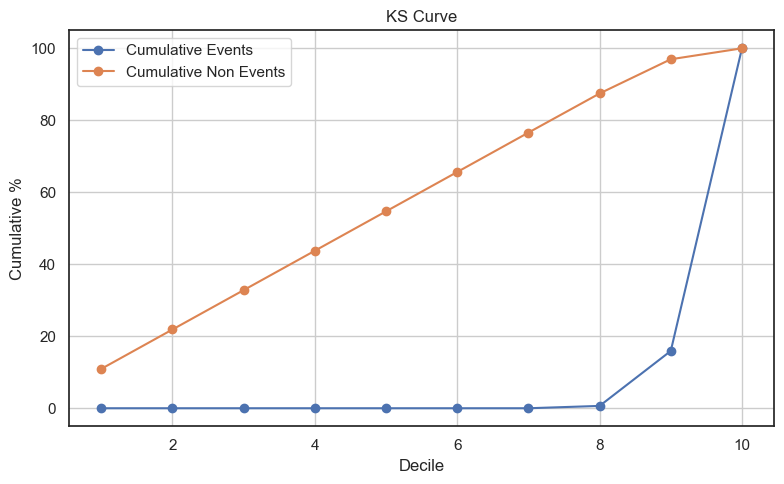

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    ks_table.index,
    ks_table['cum_event_pct'],
    marker='o',
    label='Cumulative Events'
)

plt.plot(
    ks_table.index,
    ks_table['cum_non_event_pct'],
    marker='o',
    label='Cumulative Non Events'
)

plt.xlabel('Decile')
plt.ylabel('Cumulative %')
plt.title('KS Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("ks.png", dpi=300, bbox_inches="tight")

plt.show()

In [113]:
from sklearn.metrics import roc_auc_score

for col in [
    'credit_utilization_ratio',
    'delinquency_ratio',
    'loan_to_income'
]:
    
    auc = roc_auc_score(
        y_test,
        X_test_encoded[col]
    )

    print(f"{col}: {auc:.4f}")

credit_utilization_ratio: 0.8871
delinquency_ratio: 0.7246
loan_to_income: 0.6946


In [114]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    best_model_brf,
    X_train_encoded,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("CV AUC Mean :", cv_auc.mean())
print("CV AUC Std  :", cv_auc.std())

CV AUC Mean : 0.9843760265451355
CV AUC Std  : 0.0014542038549749928


## ROC-AUC and Gini Coefficient Evaluation

The Receiver Operating Characteristic (ROC) Curve and Area Under the Curve (AUC) were used to assess the model's ability to distinguish between default and non-default borrowers across different classification thresholds.

The Gini Coefficient was also calculated as an additional measure of model discrimination and is derived from the ROC-AUC score.

### Interpretation
- The training ROC-AUC of **0.9985** and testing ROC-AUC of **0.9867** indicate excellent discriminatory power.
- The difference between training and testing AUC values is only **0.0118**, suggesting minimal performance degradation on unseen data.
- To further investigate potential overfitting, a **5-Fold Cross Validation** was performed.
- The model achieved a **mean cross-validation ROC-AUC of 0.9843** with a **standard deviation of 0.0015**, indicating highly consistent performance across different data subsets.
- The extremely low variation in cross-validation scores confirms that the model is stable and generalizes well.
- The test Gini coefficient of **0.9734** further validates the model's strong ability to separate default and non-default borrowers.

### Conclusion
Although the model achieved exceptionally high predictive performance, the small train-test performance gap combined with the highly stable cross-validation results provides strong evidence that the model is not significantly overfitted. The Balanced Random Forest model demonstrates excellent generalization capability and robust predictive performance on unseen data.

In [115]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# Get default probabilities
y_pred_proba = best_model_brf.predict_proba(X_test_encoded)[:, 1]

threshold_data = []

for th in np.arange(0.10, 0.90, 0.05):
    
    y_pred_custom = (y_pred_proba >= th).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    threshold_data.append({
        "Threshold": round(th, 2),
        "Precision (Catch Accuracy)": round(precision, 3),
        "Recall (Defaults Caught)": round(recall, 3),
        "F1-Score": round(f1, 3),
        "False Alarms (Lost Customers)": fp,
        "Missed Defaults (Bad Loans)": fn
    })

df_thresholds = pd.DataFrame(threshold_data)

display(df_thresholds)

,Threshold,Precision (Catch Accuracy),Recall (Defaults Caught),F1-Score,False Alarms (Lost Customers),Missed Defaults (Bad Loans)
0,0.100,0.279,1.000,0.436,2774,0
1,0.150,0.325,0.999,0.490,2231,1
2,0.200,0.363,0.997,0.532,1881,3
3,0.250,0.400,0.995,0.570,1605,5
4,0.300,0.439,0.993,0.609,1364,7
5,0.350,0.474,0.990,0.641,1181,11
6,0.400,0.516,0.985,0.677,994,16
7,0.450,0.546,0.973,0.699,869,29
8,0.500,0.580,0.960,0.723,746,43
9,0.550,0.607,0.946,0.740,657,58


### Cross-Validation Performance Evaluation

To assess the robustness and generalization capability of the final Balanced Random Forest model, **5-Fold Cross-Validation** was performed using the ROC-AUC metric.

Cross-validation helps ensure that the model's performance is not dependent on a particular train-test split and provides a more reliable estimate of how the model will perform on unseen data.


### Interpretation

- The model achieved an average **ROC-AUC of 0.9843**, indicating excellent discriminatory power between default and non-default borrowers.
- The very low standard deviation (**0.0015**) demonstrates that the model produces highly consistent results across different validation folds.
- The small variation in performance suggests that the model is stable and does not suffer from significant overfitting.
- These results validate the model's ability to generalize well to unseen data and confirm the reliability of the selected features and modeling approach.

### Conclusion

The cross-validation results indicate that the Balanced Random Forest model is both **highly accurate and stable**. The consistently high ROC-AUC across all folds provides strong evidence that the model can effectively identify credit default risk and maintain its predictive performance on new datasets.

In [116]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       37488 non-null  float64
 1   number_of_open_accounts   37488 non-null  float64
 2   credit_utilization_ratio  37488 non-null  float64
 3   delinquency_ratio         37488 non-null  float64
 4   monthly_installment       37488 non-null  float64
 5   loan_to_income            37488 non-null  float64
 6   residence_type_Owned      37488 non-null  bool   
 7   residence_type_Rented     37488 non-null  bool   
 8   loan_purpose_Education    37488 non-null  bool   
 9   loan_purpose_Home         37488 non-null  bool   
 10  loan_purpose_Personal     37488 non-null  bool   
 11  loan_type_Unsecured       37488 non-null  bool   
dtypes: bool(6), float64(6)
memory usage: 2.2 MB


In [140]:
cols_to_scale = X_train_encoded.select_dtypes(include=['float64', 'int64']).columns

scaler = MinMaxScaler()

X_train_encoded[cols_to_scale] = scaler.fit_transform(
    X_train_encoded[cols_to_scale]
)

X_test_encoded[cols_to_scale] = scaler.transform(
    X_test_encoded[cols_to_scale]
)

In [141]:
best_model_brf.fit(X_train_encoded, y_train)

,n_estimators,180
,criterion,'gini'
,max_depth,17
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [142]:
import joblib

joblib.dump(
    {
        "model": best_model_brf,
        "scaler": scaler,
        "features": X_train_encoded.columns.tolist(),
        "cols_to_scale": cols_to_scale,
    },
    "artifacts/brf_model.pkl",
)


['artifacts/brf_model.pkl']

In [ ]:
artifact = joblib.load("brf_model.pkl")

print(hasattr(artifact["scaler"], "data_min_"))

In [ ]:
artifact = joblib.load(r"C:\Users\jayas\OneDrive\Desktop\ML and DL\Credit-Risk-Model\artifacts\brf_model.pkl")

print(hasattr(artifact["scaler"], "data_min_"))

In [ ]:
df.info()

In [ ]:
df[['loan_amount', 'principal_outstanding']].describe()

In [ ]:
# Create a copy
risk_df = df.copy()

# PD from trained XGBoost model
risk_df['PD'] = best_model_brf.predict_proba(X_test_encoded)[:, 1]

# EAD using principal outstanding
risk_df['EAD'] = risk_df['principal_outstanding']

# LGD assumptions
risk_df['LGD'] = np.where(
    risk_df['loan_type'] == 'Unsecured',
    0.70,
    0.35
)

# Expected Loss
risk_df['Expected_Loss'] = (
    risk_df['PD']
    * risk_df['LGD']
    * risk_df['EAD']
)

# Keep only important columns
credit_risk_results = risk_df[
    [
        'cust_id',
        'loan_id',
        'loan_type',
        'loan_amount',
        'principal_outstanding',
        'default',
        'PD',
        'LGD',
        'EAD',
        'Expected_Loss'
    ]
]

credit_risk_results.head()

## Probability of Default (PD)

Probability of Default (PD) represents the likelihood that a borrower will default on their loan obligations within a specified time horizon. PD is one of the primary components of credit risk modeling and serves as the foundation for estimating expected credit losses.

In this project, PD was estimated using the final Balanced Random Forest (BRF) model, which was selected based on its superior performance in terms of recall, ROC-AUC, KS Statistic, and cross-validation stability.

### PD Calculation

The predicted probability of default generated by the Balanced Random Forest model was used as the borrower's PD score.

```python
risk_df['PD'] = best_model_brf.predict_proba(X_test_encoded)[:, 1]
```

### Interpretation

- PD values range between 0 and 1.
- A higher PD indicates a greater likelihood of default.
- For example, a PD of 0.80 suggests an estimated 80% probability that the borrower may default.
- PD scores were subsequently used in the Expected Loss (EL) calculation.

## Exposure at Default (EAD)

Exposure at Default (EAD) represents the total amount that a lender is exposed to when a borrower defaults. It measures the outstanding balance that remains at risk at the time of default.

In this project, the Principal Outstanding amount was used as the Exposure at Default because it directly reflects the unpaid portion of the loan that remains recoverable by the lender.

### EAD Calculation

```python
risk_df['EAD'] = risk_df['principal_outstanding']
```

### Rationale

- Principal Outstanding represents the remaining unpaid loan balance.
- It provides a realistic estimate of the lender's financial exposure if a borrower defaults.
- Higher EAD values indicate larger potential losses.

### Interpretation

| EAD Level | Risk Interpretation |
|------------|------------|
| Low EAD | Limited financial exposure |
| Medium EAD | Moderate financial exposure |
| High EAD | Significant financial exposure |
| Very High EAD | Critical financial exposure |

### Importance of EAD

EAD is a key component of credit risk measurement and is used together with PD and LGD to estimate Expected Loss (EL).

A borrower with a high Probability of Default but low EAD may contribute less risk than a borrower with a moderate Probability of Default and a very high EAD.

## Loss Given Default (LGD)

Loss Given Default (LGD) represents the proportion of exposure that is expected to be lost when a borrower defaults after considering potential recoveries.

Since the dataset did not contain actual recovery amounts, a rule-based LGD estimation approach was adopted based on the type of loan.

### LGD Assumptions

The following assumptions were used:

| Loan Type | LGD |
|------------|------------|
| Unsecured Loan | 70% |
| Secured Loan | 35% |

### Rationale

- **Unsecured loans** do not have collateral backing the credit exposure. Therefore, recovery opportunities are limited in the event of default, resulting in a higher expected loss. Based on this assumption, an LGD of **70%** was assigned.

- **Secured loans** are backed by collateral such as property, vehicles, or other assets. Financial institutions can recover a portion of the outstanding exposure through collateral liquidation, resulting in a lower expected loss. Therefore, an LGD of **35%** was assigned.

### Calculation

The LGD values were assigned using the following rule:

```python
risk_df['LGD'] = np.where(
    risk_df['loan_type'] == 'Unsecured',
    0.70,
    0.35
)
```

### Interpretation

A higher LGD indicates a greater expected loss if the borrower defaults. By assigning different LGD values to secured and unsecured loans, the model incorporates the impact of collateral on potential recovery rates and produces a more realistic estimate of credit risk.

### Conclusion

The rule-based LGD methodology provides a practical approximation of loss severity in the absence of actual recovery data. This approach aligns with standard credit risk management principles where unsecured lending typically exhibits significantly higher loss rates than secured lending.

In [ ]:
print("Total Expected Loss:",
      round(credit_risk_results['Expected_Loss'].sum(), 2))

print("Average Expected Loss:",
      round(credit_risk_results['Expected_Loss'].mean(), 2))

In [ ]:
top_risk = credit_risk_results.sort_values(
    'Expected_Loss',
    ascending=False
)

top_risk.head(20)

In [ ]:
top_risk.info()

### Expected Loss Analysis

Expected Loss (EL) was calculated using the standard credit risk framework:

EL = PD × LGD × EAD

where:

- PD (Probability of Default) was estimated using the final Balanced Random Forest model.
- LGD (Loss Given Default) was assigned based on loan type assumptions (70% for unsecured loans and 35% for secured loans).
- EAD (Exposure at Default) was represented by the principal outstanding amount.

### Portfolio Results

| Metric | Value |
|----------|----------:|
| Total Expected Loss | ₹113,913,940.58 |
| Average Expected Loss | ₹9,115.03 |

### Key Findings

- Borrowers with high Probability of Default (PD), large outstanding balances (EAD), and unsecured loan exposure generated the highest Expected Loss values.
- Unsecured loans contributed disproportionately to portfolio risk due to their higher assumed LGD.
- The Expected Loss framework enabled identification of the most financially significant high-risk borrowers for enhanced monitoring and risk management.

In [ ]:
credit_risk_results['Risk_Category'] = pd.cut(
    credit_risk_results['PD'],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [ ]:
# Expected Loss by category
risk_summary = (
    credit_risk_results
    .groupby('Risk_Category', observed=False)['Expected_Loss']
    .sum()
    .reset_index()
)

# Customer count by category
risk_counts = (
    credit_risk_results['Risk_Category']
    .value_counts()
    .reset_index()
)

risk_counts.columns = [
    'Risk_Category',
    'Customer_Count'
]

# Merge both tables
risk_dashboard = pd.merge(
    risk_counts,
    risk_summary,
    on='Risk_Category',
    how='left'
)
risk_dashboard

## Expected Loss (EL)

Expected Loss represents the average credit loss expected from a borrower and combines Probability of Default (PD), Exposure at Default (EAD), and Loss Given Default (LGD).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    risk_df['PD'],
    bins=30,
    kde=True
)

plt.title('Probability of Default (PD) Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Probability of Default')
plt.ylabel('Number of Borrowers')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pd.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    risk_df['Expected_Loss'],
    bins=40,
    kde=True
)

plt.yscale('log')

plt.title('Expected Loss Distribution Across Borrowers',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Expected Loss (₹)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(alpha=0.3)
plt.savefig("expected_loss.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()